# Results Registry Control Room

This notebook is the single entry point for the result state of the codebase: source locations, copied registry files, generated summaries, missing-data status, and archive notes.

## Registry Snapshot

- Registry root: [`experiments/output/result_registry`](../experiments/output/result_registry)
- Tracked result keys: **40**
- Complete: **4**
- Partial: **10**
- Missing source: **26**
- Copied source rows: **4,824**
- Registry size: about **456 MiB**
- Original scattered files were **not moved or deleted**.

## Start Here

- Registry README: [`README.md`](../experiments/output/result_registry/README.md)
- Consolidation plan: [`result_consolidation_plan.md`](../experiments/output/result_registry/inventory/result_consolidation_plan.md)
- Consolidated status: [`consolidated_status.md`](../experiments/output/result_registry/status/consolidated_status.md)
- Notebook utility: [`tmlr_result_utils.py`](tmlr_result_utils.py)

## Inventories And Manifests

- Current result inventory: [`current_result_inventory.csv`](../experiments/output/result_registry/inventory/current_result_inventory.csv)
- Source file manifest: [`source_file_manifest.csv`](../experiments/output/result_registry/inventory/source_file_manifest.csv)
- Missing source paths: [`missing_source_paths.csv`](../experiments/output/result_registry/inventory/missing_source_paths.csv)
- Archive manifest: [`archive_manifest.csv`](../experiments/output/result_registry/archive/archive_manifest.csv)
- Older path manifest: [`result_path_manifest.csv`](../experiments/output/result_registry/inventory/result_path_manifest.csv)

## Summary CSVs

- Planetoid summary: [`planetoid_results_summary.csv`](../experiments/output/result_registry/summaries/planetoid_results_summary.csv)
- Large-scale summary: [`large_scale_results_summary.csv`](../experiments/output/result_registry/summaries/large_scale_results_summary.csv)
- Heterophily summary: [`heterophily_results_summary.csv`](../experiments/output/result_registry/summaries/heterophily_results_summary.csv)

## Section Status Reports

- Planetoid status: [`planetoid_results_status.md`](../experiments/output/result_registry/status/planetoid_results_status.md)
- Large-scale status: [`large_scale_results_status.md`](../experiments/output/result_registry/status/large_scale_results_status.md)
- Heterophily status: [`heterophily_results_status.md`](../experiments/output/result_registry/status/heterophily_results_status.md)

## Copied Source Roots

- Canonical R1/R1b CSVs: [`sources/canonical`](../experiments/output/result_registry/sources/canonical)
- Planetoid sources: [`sources/planetoid`](../experiments/output/result_registry/sources/planetoid)
- Large-scale sources: [`sources/large_scale`](../experiments/output/result_registry/sources/large_scale)
- Heterophily sources: [`sources/heterophily`](../experiments/output/result_registry/sources/heterophily)
- Non-destructive archive copies: [`archive/superseded_tables`](../experiments/output/result_registry/archive/superseded_tables)

## Important Caveats

- Amazon Computers GCN hop-2 is smoke-only: three 1-repetition datapoints at beta 10000.
- Amazon Photo has R7 configs but no usable result datapoints recovered.
- Heterophily Texas/Wisconsin data is overlapping Phase 6 evidence, not full top-level R6.
- APPNP exists in Phase 6 but is not part of top-level R6.


# 7. Experimental Results

## Opening paragraph for Section 7

This section evaluates FedProp along five axes: accuracy, communication efficiency, backbone-agnosticity, robustness to graph regimes, and scalability with increasing client fragmentation. We distinguish two information regimes throughout the results. **FedProp-L1** denotes the strict local-topology setting, where each client uses only local graph information and boundary incidence. **FedProp-L2** denotes a relaxed topology setting, where additional two-hop topological information is available through a one-time setup. We use FedProp-L2 as the primary comparison setting against neighborhood-aware baselines such as FedGCN and FedGAT, while retaining FedProp-L1 to show the strict communication-free regime.

---

# 7.1 Accuracy–Communication Tradeoff: FedProp’s Primary Advantage

## Purpose

This subsection should come first. It teaches the reviewer how to interpret the rest of the results.

Core message:

> FedProp is not presented as a universal accuracy-SOTA method. Its main advantage is recovering missing-neighbor performance while avoiding feature or embedding exchange between clients.

## Figure 1 — Accuracy vs. communication cost

**Title:** Accuracy–communication tradeoff across federated GNN methods.

**What it shows:**

Scatter plot.

**X-axis:** additional neighbor-information communication cost
Examples:

* bytes per client
* total extra communication
* log-scale communication cost
* or normalized communication overhead relative to FedAvg

**Y-axis:** test accuracy.

**Methods to include:**

* FedProp-Zero
* FedProp-L1
* FedProp-L2
* FedGCN-1hop
* FedGCN-2hop
* FedGAT
* FedCog, optional reference point if clearly labeled
* FedSage+/FedDEP, optional if using literature/protocol positioning

**Datasets:**
Use Cora as the clean primary plot. Add OGBN-Arxiv as a second panel if the communication numbers are stable.

**Caption draft:**

> Accuracy–communication tradeoff on Cora under federated subgraph learning. FedProp improves substantially over the zero-hop baseline while requiring no feature or embedding exchange between clients. FedProp-L2 is shown as a relaxed topology setting for comparison with neighborhood-aware baselines such as FedGCN and FedGAT.




In [3]:

# Figure 1 — Accuracy–communication tradeoff: data gaps
from IPython.display import display, HTML
import pandas as pd

# Figure 1 needs two values per method: test accuracy (y-axis) and communication cost (x-axis).
# Accuracy comes from our summary CSVs. Communication cost is NOT tracked anywhere — needs computing.

rows = [
    # (method, accuracy_status, comm_status, acc_source, comm_description)
    ('FedProp-Zero',
        '🟢 have',      '🟢 zero by definition',
        'planetoid_results_summary.csv (Zero-hop)',
        'Zero extra comm — this is the FedAvg baseline point'),
    ('FedProp-L1 (Adj)',
        '🟢 have',      '🔴 need to compute',
        'planetoid_results_summary.csv (FedProp-Adj, hop=1)',
        'One-time boundary adjacency exchange: |E_boundary| × 8 bytes (int32 src/dst pairs)'),
    ('FedProp-L1 (Diff)',
        '🟢 have',      '🔴 need to compute',
        'planetoid_results_summary.csv (FedProp-Diff, hop=1)',
        'Same as Adj-L1 — same topology info, different operator'),
    ('FedProp-L2 (Adj)',
        '🟡 prelim (3 reps)', '🔴 need to compute',
        'planetoid_results_summary.csv (FedProp-Adj, hop=2)',
        'One-time 2-hop topology: larger than L1, still one-off (no per-round cost)'),
    ('FedProp-L2 (Diff)',
        '🟡 prelim (3 reps)', '🔴 need to compute',
        'planetoid_results_summary.csv (FedProp-Diff, hop=2)',
        'Same as Adj-L2'),
    ('FedGCN-1hop',
        '🔴 not run',   '🔴 not run',
        '—',
        'Per-round: K rounds × |boundary_nodes| × feat_dim × 4 bytes'),
    ('FedGCN-2hop',
        '🔴 not run',   '🔴 not run',
        '—',
        'Per-round: K rounds × |2-hop boundary| × feat_dim × 4 bytes (larger than 1-hop)'),
    ('FedGAT',
        '🔴 not run',   '🔴 not run',
        '—',
        'Per-round: K rounds × |boundary| × hidden_dim × 4 bytes (embeddings, not raw features)'),
    ('FedCog',
        '⚪ literature only', '⚪ literature only',
        'Different partition protocol — not directly comparable',
        'Border embedding exchange; protocol differs from ours'),
    ('FedSage+',
        '⚪ literature only', '⚪ literature only',
        'Different partition + split protocol',
        'Generator-based; protocol differs'),
    ('FedDEP',
        '⚪ literature only', '⚪ literature only',
        'Different partition + split protocol',
        'Generator-based; protocol differs'),
]

df = pd.DataFrame(rows, columns=['method', 'accuracy (y-axis)', 'comm cost (x-axis)', 'accuracy source', 'comm cost formula'])

BG = {'🟢': '#d4edda', '🟡': '#fff3cd', '🔴': '#f8d7da', '⚪': '#e9ecef'}
FG = {'🟢': '#155724', '🟡': '#7a5c00', '🔴': '#721c24', '⚪': '#495057'}

def _style_cell(val):
    for icon, bg in BG.items():
        if str(val).startswith(icon):
            return f'background-color:{bg}; color:{FG[icon]}; font-weight:bold'
    return ''

styled = (
    df.style
    .map(_style_cell, subset=['accuracy (y-axis)', 'comm cost (x-axis)'])
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'),
                                     ('text-align', 'left'), ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('border-bottom', '1px solid #dee2e6')]},
    ])
    .hide(axis='index')
)

display(HTML(
    '<h4 style="margin-bottom:4px">Figure 1 — Data Gap Analysis</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px; margin-bottom:8px">'
    '🟢 have &nbsp;·&nbsp; 🟡 partial &nbsp;·&nbsp; 🔴 missing / not run &nbsp;·&nbsp; ⚪ literature-only (different protocol)'
    '</p>'
    '<p style="color:#721c24; font-size:0.88em; background:#f8d7da; padding:6px 10px; border-radius:4px; margin-bottom:8px">'
    '<strong>Blocking gap:</strong> communication cost is not tracked in any result CSV. '
    'Must be computed from graph statistics (|boundary edges|, feature dim, #rounds) before Figure 1 can be plotted. '
    'FedGCN and FedGAT also need to be run.'
    '</p>'
))
display(styled)


method,accuracy (y-axis),comm cost (x-axis),accuracy source,comm cost formula
FedProp-Zero,🟢 have,🟢 zero by definition,planetoid_results_summary.csv (Zero-hop),Zero extra comm — this is the FedAvg baseline point
FedProp-L1 (Adj),🟢 have,🔴 need to compute,"planetoid_results_summary.csv (FedProp-Adj, hop=1)",One-time boundary adjacency exchange: |E_boundary| × 8 bytes (int32 src/dst pairs)
FedProp-L1 (Diff),🟢 have,🔴 need to compute,"planetoid_results_summary.csv (FedProp-Diff, hop=1)","Same as Adj-L1 — same topology info, different operator"
FedProp-L2 (Adj),🟡 prelim (3 reps),🔴 need to compute,"planetoid_results_summary.csv (FedProp-Adj, hop=2)","One-time 2-hop topology: larger than L1, still one-off (no per-round cost)"
FedProp-L2 (Diff),🟡 prelim (3 reps),🔴 need to compute,"planetoid_results_summary.csv (FedProp-Diff, hop=2)",Same as Adj-L2
FedGCN-1hop,🔴 not run,🔴 not run,—,Per-round: K rounds × |boundary_nodes| × feat_dim × 4 bytes
FedGCN-2hop,🔴 not run,🔴 not run,—,Per-round: K rounds × |2-hop boundary| × feat_dim × 4 bytes (larger than 1-hop)
FedGAT,🔴 not run,🔴 not run,—,"Per-round: K rounds × |boundary| × hidden_dim × 4 bytes (embeddings, not raw features)"
FedCog,⚪ literature only,⚪ literature only,Different partition protocol — not directly comparable,Border embedding exchange; protocol differs from ours
FedSage+,⚪ literature only,⚪ literature only,Different partition + split protocol,Generator-based; protocol differs


## Table 1 — Communication and information summary

**Title:** Communication and information requirements of compared methods.

**Columns:**

* Method
* Information regime
* Requires raw feature exchange?
* Requires hidden embedding exchange?
* Requires generator?
* Requires topology setup?
* Per-round neighbor communication?
* Extra communication beyond FedAvg
* Accuracy used in Figure 1
* Gap closed %

**Rows:**

* FedProp-Zero
* FedProp-L1
* FedProp-L2
* FedGCN-1hop
* FedGCN-2hop
* FedGAT
* FedCog
* FedSage+
* FedDEP

**Key wording under the table:**

> FedProp-L1 and FedProp-L2 preserve the same model-update communication pattern as FedAvg during training. FedProp-L2 differs from FedProp-L1 in its topology assumption and should be interpreted as a relaxed-information setting, not as the strict privacy model.

---

In [4]:

# Table 1 — Communication and information summary: data gaps
# Table 1 is a protocol comparison table, not an experimental results table.
# The protocol columns (feature exchange?, generator?, etc.) are known from design knowledge.
# The experimental columns (accuracy, gap closed %) depend on running the baselines.
from IPython.display import display, HTML
import pandas as pd
from pathlib import Path

REGISTRY      = Path('/home/bosho/FP/experiments/output/result_registry')
planetoid     = pd.read_csv(REGISTRY / 'summaries/planetoid_results_summary.csv')

# ── Partial Table 1 preview (protocol columns — known from design) ────────────
# Accuracy and gap-closed % are placeholders until baselines are run.
# Cora IID (β=10000) used as representative point throughout.

def _acc(method, hop, pe='no', beta=10000, ds='Cora'):
    prop_map = {'FedProp-Zero':'Zero-hop', 'FedProp-L1 (Adj)':'FedProp-Adj',
                'FedProp-L1 (Diff)':'FedProp-Diff', 'FedProp-L2 (Adj)':'FedProp-Adj',
                'FedProp-L2 (Diff)':'FedProp-Diff'}
    m = prop_map.get(method)
    if m is None:
        return '—'
    r = planetoid[(planetoid.dataset==ds)&(planetoid.model=='GCN')&
                  (planetoid.hop==hop)&(planetoid.method==m)&
                  (planetoid.PE==pe)&(planetoid.beta==beta)]
    if r.empty: return '—'
    row = r.iloc[0]
    flag = '†' if row.n_reps < 10 else ''
    return f"{row.mean_acc_pct:.1f}{flag}"

def _gap(method, hop, pe='no', beta=10000, ds='Cora'):
    acc_str = _acc(method, hop, pe, beta, ds)
    if acc_str == '—': return '—'
    acc_val = float(acc_str.rstrip('†'))
    zero = planetoid[(planetoid.dataset==ds)&(planetoid.model=='GCN')&
                     (planetoid.hop==1)&(planetoid.method=='Zero-hop')&
                     (planetoid.PE=='no')&(planetoid.beta==beta)]
    full = planetoid[(planetoid.dataset==ds)&(planetoid.model=='GCN')&
                     (planetoid.hop==1)&(planetoid.method=='Full-graph')&
                     (planetoid.PE=='no')&(planetoid.beta==beta)]
    if zero.empty or full.empty: return '—'
    z, f = zero.iloc[0].mean_acc_pct, full.iloc[0].mean_acc_pct
    if abs(f - z) < 1e-6: return '—'
    pct = (acc_val - z) / (f - z) * 100
    return f"{pct:.0f}%"

protocol_rows = [
    # method, info_regime, feat_xchg, embed_xchg, generator, topo_setup, per_round_comm, extra_beyond_fedavg
    ('FedProp-Zero',     'L0 — no topology', 'No', 'No', 'No', 'No',           'No',  'None'),
    ('FedProp-L1 (Adj)', 'L1 — 1-hop local', 'No', 'No', 'No', 'One-time',    'No',  'One-time boundary topology'),
    ('FedProp-L1 (Diff)','L1 — 1-hop local', 'No', 'No', 'No', 'One-time',    'No',  'One-time boundary topology'),
    ('FedProp-L2 (Adj)', 'L2 — 2-hop relax', 'No', 'No', 'No', 'One-time',    'No',  'One-time 2-hop topology'),
    ('FedProp-L2 (Diff)','L2 — 2-hop relax', 'No', 'No', 'No', 'One-time',    'No',  'One-time 2-hop topology'),
    ('FedGCN-1hop',      'neighbor features', 'Yes','No', 'No', 'No',          'Yes', 'Per-round: boundary features'),
    ('FedGCN-2hop',      'neighbor features', 'Yes','No', 'No', 'No',          'Yes', 'Per-round: 2-hop boundary features'),
    ('FedGAT',           'neighbor embeds',   'No', 'Yes','No', 'No',          'Yes', 'Per-round: boundary embeddings'),
    ('FedCog',           'border embeddings', 'No', 'Yes','No', 'No',          'Yes', 'Per-round: border node embeddings'),
    ('FedSage+',         'generated features','Yes','No', 'Yes','No',          'Yes', 'Per-round: generated neighbor feats'),
    ('FedDEP',           'generated features','Yes','No', 'Yes','No',          'Yes', 'Per-round: generated neighbor feats'),
]

records = []
for row in protocol_rows:
    m = row[0]
    hop = 2 if 'L2' in m else 1
    records.append({
        'Method':              m,
        'Info regime':         row[1],
        'Raw feat exchange':   row[2],
        'Embed exchange':      row[3],
        'Generator':           row[4],
        'Topology setup':      row[5],
        'Per-round comm':      row[6],
        'Extra beyond FedAvg': row[7],
        'Acc (Cora IID)':      _acc(m, hop),
        'Gap closed':          _gap(m, hop),
    })

df_t1 = pd.DataFrame(records)

STATUS_ROWS = [
    # (method, protocol_cols, accuracy_col, gap_closed_col, note)
    ('FedProp-Zero',      '🟢 known', '🟢 have',           '🟢 computable',      '—'),
    ('FedProp-L1 (Adj)',  '🟢 known', '🟢 have',           '🟢 computable',      '—'),
    ('FedProp-L1 (Diff)', '🟢 known', '🟢 have',           '🟢 computable',      '—'),
    ('FedProp-L2 (Adj)',  '🟢 known', '🟡 prelim (3 reps)','🟡 prelim',          '—'),
    ('FedProp-L2 (Diff)', '🟢 known', '🟡 prelim (3 reps)','🟡 prelim',          '—'),
    ('FedGCN-1hop',       '🟢 known', '🔴 not run',        '🔴 not run',         'Run FedGCN experiments'),
    ('FedGCN-2hop',       '🟢 known', '🔴 not run',        '🔴 not run',         'Run FedGCN experiments'),
    ('FedGAT',            '🟢 known', '🔴 not run',        '🔴 not run',         'Run FedGAT experiments'),
    ('FedCog',            '🟢 known', '⚪ literature',     '⚪ literature',      'Different protocol — indicative only'),
    ('FedSage+',          '🟢 known', '⚪ literature',     '⚪ literature',      'Different protocol — indicative only'),
    ('FedDEP',            '🟢 known', '⚪ literature',     '⚪ literature',      'Different protocol — indicative only'),
]

df_status = pd.DataFrame(STATUS_ROWS,
    columns=['Method', 'Protocol cols', 'Accuracy col', 'Gap closed col', 'Pending action'])

BG = {'🟢': '#d4edda', '🟡': '#fff3cd', '🔴': '#f8d7da', '⚪': '#e9ecef'}
FG = {'🟢': '#155724', '🟡': '#7a5c00', '🔴': '#721c24', '⚪': '#495057'}

def _sc(val):
    for icon, bg in BG.items():
        if str(val).startswith(icon):
            return f'background-color:{bg}; color:{FG[icon]}; font-weight:bold'
    return ''

STATUS_COLS = ['Protocol cols', 'Accuracy col', 'Gap closed col']

styled_status = (
    df_status.style
    .map(_sc, subset=STATUS_COLS)
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'),
                                     ('text-align', 'left'), ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('border-bottom', '1px solid #dee2e6')]},
    ])
    .hide(axis='index')
)

styled_preview = (
    df_t1.style
    .set_properties(**{'text-align': 'left', 'font-size': '0.85em'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#495057'), ('color', 'white'),
                                     ('text-align', 'left'), ('padding', '5px 8px')]},
        {'selector': 'td', 'props': [('padding', '4px 8px'), ('border-bottom', '1px solid #dee2e6')]},
    ])
    .hide(axis='index')
)

display(HTML(
    '<h4 style="margin-bottom:4px">Table 1 — Column Completion Status</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px; margin-bottom:8px">'
    '🟢 have &nbsp;·&nbsp; 🟡 partial &nbsp;·&nbsp; 🔴 missing / not run &nbsp;·&nbsp; ⚪ literature-only (different protocol)'
    '</p>'
    '<p style="color:#856404; font-size:0.88em; background:#fff3cd; padding:6px 10px; border-radius:4px; margin-bottom:8px">'
    '<strong>Note:</strong> Protocol columns (feature exchange, generator, etc.) are fully known from design. '
    'Accuracy and gap-closed columns need FedGCN/FedGAT experiments to be run.'
    '</p>'
))
display(styled_status)

display(HTML(
    '<h4 style="margin-top:20px; margin-bottom:4px">Table 1 — Protocol Preview (Cora IID, β=10000)</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px; margin-bottom:8px">'
    'Protocol columns are complete. Acc and Gap closed show — for unrun baselines.'
    '</p>'
))
display(styled_preview)


Method,Protocol cols,Accuracy col,Gap closed col,Pending action
FedProp-Zero,🟢 known,🟢 have,🟢 computable,—
FedProp-L1 (Adj),🟢 known,🟢 have,🟢 computable,—
FedProp-L1 (Diff),🟢 known,🟢 have,🟢 computable,—
FedProp-L2 (Adj),🟢 known,🟡 prelim (3 reps),🟡 prelim,—
FedProp-L2 (Diff),🟢 known,🟡 prelim (3 reps),🟡 prelim,—
FedGCN-1hop,🟢 known,🔴 not run,🔴 not run,Run FedGCN experiments
FedGCN-2hop,🟢 known,🔴 not run,🔴 not run,Run FedGCN experiments
FedGAT,🟢 known,🔴 not run,🔴 not run,Run FedGAT experiments
FedCog,🟢 known,⚪ literature,⚪ literature,Different protocol — indicative only
FedSage+,🟢 known,⚪ literature,⚪ literature,Different protocol — indicative only


Method,Info regime,Raw feat exchange,Embed exchange,Generator,Topology setup,Per-round comm,Extra beyond FedAvg,Acc (Cora IID),Gap closed
FedProp-Zero,L0 — no topology,No,No,No,No,No,None,59.7,-0%
FedProp-L1 (Adj),L1 — 1-hop local,No,No,No,One-time,No,One-time boundary topology,71.6,59%
FedProp-L1 (Diff),L1 — 1-hop local,No,No,No,One-time,No,One-time boundary topology,69.7,49%
FedProp-L2 (Adj),L2 — 2-hop relax,No,No,No,One-time,No,One-time 2-hop topology,75.1†,76%
FedProp-L2 (Diff),L2 — 2-hop relax,No,No,No,One-time,No,One-time 2-hop topology,74.8†,75%
FedGCN-1hop,neighbor features,Yes,No,No,No,Yes,Per-round: boundary features,—,—
FedGCN-2hop,neighbor features,Yes,No,No,No,Yes,Per-round: 2-hop boundary features,—,—
FedGAT,neighbor embeds,No,Yes,No,No,Yes,Per-round: boundary embeddings,—,—
FedCog,border embeddings,No,Yes,No,No,Yes,Per-round: border node embeddings,—,—
FedSage+,generated features,Yes,No,Yes,No,Yes,Per-round: generated neighbor feats,—,—


# 7.2 Main GCN Accuracy Results

## Purpose

This is the main numerical table for the paper.

Core message:

> Under a GCN backbone, FedProp-L2 is competitive with FedGCN while avoiding neighbor-feature exchange. FedProp-L1 establishes the strict local-information baseline.



## Table 2 — Main GCN accuracy table

**Title:** Node classification accuracy under GCN backbone.

**Datasets:**

* Cora
* Citeseer
* Pubmed
* OGBN-Arxiv
* Texas
* Wisconsin

You can split the table into two blocks:

**Block A: Homophilic datasets**

* Cora
* Citeseer
* Pubmed
* OGBN-Arxiv

**Block B: Heterophilic datasets**

* Texas
* Wisconsin

**Methods:**

* Centralized GCN
* FedProp-Zero
* FedProp-Full / Oracle
* FedProp-Adj-L1
* FedProp-Diff-L1
* FedProp-Adj-L2
* FedProp-Diff-L2
* FedGCN-1hop
* FedGCN-2hop, optional if available

**Columns:**
Option A:

| Method | Cora IID | Cora non-IID | Citeseer IID | Citeseer non-IID | Pubmed IID | Pubmed non-IID | OGBN IID | OGBN non-IID |
| ------ | -------: | -----------: | -----------: | ---------------: | ---------: | -------------: | -------: | -----------: |

Then a lower block:

| Method | Texas IID | Texas non-IID | Wisconsin IID | Wisconsin non-IID |
| ------ | --------: | ------------: | ------------: | ----------------: |

Option B, if table gets wide:

| Dataset | Regime | Centralized | Zero | Full | FedProp-L1 | FedProp-L2 | FedGCN |
| ------- | ------ | ----------: | ---: | ---: | ---------: | ---------: | -----: |

I recommend **Option B**. It is easier to read.

**Table notes:**

* Report mean ± std.
* Bold best federated non-oracle method.
* Underline best FedProp variant.
* Mark L1 and L2 explicitly.
* Use β labels in the table: β=10000 for IID, β=10 or β=1 for non-IID.

**Caption draft:**

> Main GCN results across homophilic, large-scale, and heterophilic graph datasets. FedProp-L2 is used as the primary comparison against neighborhood-aware federated baselines, while FedProp-L1 reports the strict local-topology setting. FedProp-Full is an oracle reference using exact remote features and is not a deployable method.



In [1]:

from pathlib import Path
import pandas as pd
from IPython.display import display

REGISTRY        = Path('/home/bosho/FP/experiments/output/result_registry')
PLANETOID_CSV   = REGISTRY / 'summaries/planetoid_results_summary.csv'
LARGE_SCALE_CSV = REGISTRY / 'summaries/large_scale_results_summary.csv'
INVENTORY_CSV   = REGISTRY / 'inventory/current_result_inventory.csv'

planetoid   = pd.read_csv(PLANETOID_CSV)
large_scale = pd.read_csv(LARGE_SCALE_CSV)
inventory   = pd.read_csv(INVENTORY_CSV)


def lookup(df, dataset, model, hop, method, pe, beta):
    """Return 'mean ± std%' string, or '—' if missing. Appends † when n_reps < 10."""
    mask = (
        (df.dataset == dataset) & (df.model == model) & (df.hop == hop) &
        (df.method == method) & (df.PE == pe) & (df.beta == beta)
    )
    rows = df[mask]
    if rows.empty:
        return '—'
    r = rows.iloc[0]
    flag = '†' if r.n_reps < 10 else ''
    return f"{r.mean_acc_pct:.1f} ± {r.std_acc_pct:.1f}{flag}"


BETAS = [(10000, 'IID (β=10k)'), (1, 'non-IID (β=1)')]
PROP  = ['FedProp-Adj', 'FedProp-Diff']

rows = []

# ── Planetoid datasets ────────────────────────────────────────────────────────
# Baselines (Zero-hop, Full-graph) and L1 FedProp come from GCN 1-hop (best replicated).
# L2 FedProp comes from GCN 2-hop prelim (3 reps each — marked †).
for ds in ['Cora', 'Citeseer', 'Pubmed']:
    for beta, regime in BETAS:
        row = {'Dataset': ds, 'Regime': regime}
        row['Zero-hop']       = lookup(planetoid, ds, 'GCN', 1, 'Zero-hop',   'no', beta)
        row['Full (oracle)']  = lookup(planetoid, ds, 'GCN', 1, 'Full-graph', 'no', beta)
        for m in PROP:
            row[f'{m} (L1)']  = lookup(planetoid, ds, 'GCN', 1, m, 'no', beta)
        for m in PROP:
            row[f'{m} (L2)']  = lookup(planetoid, ds, 'GCN', 2, m, 'no', beta)
        row['FedGCN'] = '—'
        rows.append(row)

# ── OGBN-Arxiv ────────────────────────────────────────────────────────────────
# GCN 2-hop is the only complete block (10 reps). GCN 1-hop has 1 smoke point only.
for beta, regime in BETAS:
    row = {'Dataset': 'OGBN-Arxiv', 'Regime': regime}
    row['Zero-hop']      = lookup(large_scale, 'ogbn-arxiv', 'GCN', 2, 'Zero-hop',   'no', beta)
    row['Full (oracle)'] = lookup(large_scale, 'ogbn-arxiv', 'GCN', 2, 'Full-graph', 'no', beta)
    for m in PROP:
        row[f'{m} (L1)'] = '—'   # 1-hop: only 1 smoke datapoint
    for m in PROP:
        row[f'{m} (L2)'] = lookup(large_scale, 'ogbn-arxiv', 'GCN', 2, m, 'no', beta)
    row['FedGCN'] = '—'
    rows.append(row)

# ── Build and display ─────────────────────────────────────────────────────────
COL_ORDER = [
    'Dataset', 'Regime',
    'Zero-hop', 'Full (oracle)',
    'FedProp-Adj (L1)', 'FedProp-Diff (L1)',
    'FedProp-Adj (L2)', 'FedProp-Diff (L2)',
    'FedGCN',
]
df_t2 = pd.DataFrame(rows)[COL_ORDER].set_index(['Dataset', 'Regime'])

print("Table 2 — Node classification accuracy under GCN backbone (mean ± std %)")
print("L1 = 1-hop (strict local)  |  L2 = 2-hop (relaxed, prelim)")
print("† = <10 reps  |  — = no data  |  oracle = Full-graph (not deployable)  |  FedGCN = not yet run")
print()
display(df_t2)

# ── Data sources ──────────────────────────────────────────────────────────────
print("\n── Sources ──────────────────────────────────────────────────────────────")
print(f"  Planetoid (GCN 1-hop + 2-hop): {PLANETOID_CSV}")
print(f"  OGBN-Arxiv (GCN 2-hop)       : {LARGE_SCALE_CSV}")
print()
KEYS = [
    'cora_gcn_1-hop', 'cora_gcn_2-hop',
    'citeseer_gcn_1-hop', 'citeseer_gcn_2-hop',
    'pubmed_gcn_1-hop', 'pubmed_gcn_2-hop',
    'ogbn-arxiv_gcn_2-hop',
]
inv_sub = (
    inventory[inventory.result_key.isin(KEYS)]
    [['result_key', 'status', 'configs', 'repetitions', 'notes']]
    .set_index('result_key')
    .loc[KEYS]
)
display(inv_sub)


Table 2 — Node classification accuracy under GCN backbone (mean ± std %)
L1 = 1-hop (strict local)  |  L2 = 2-hop (relaxed, prelim)
† = <10 reps  |  — = no data  |  oracle = Full-graph (not deployable)  |  FedGCN = not yet run



Zero-hop Full (oracle) FedProp-Adj (L1)  \
Dataset    Regime                                                      
Cora       IID (β=10k)     59.7 ± 1.8    79.9 ± 0.7       71.6 ± 1.7   
           non-IID (β=1)   65.7 ± 2.7    81.1 ± 0.5       76.6 ± 1.5   
Citeseer   IID (β=10k)     58.7 ± 1.5    69.7 ± 0.4       63.8 ± 1.5   
           non-IID (β=1)  61.5 ± 1.5†    69.6 ± 0.8       66.3 ± 1.4   
Pubmed     IID (β=10k)     69.6 ± 3.4    77.9 ± 1.1       77.4 ± 1.3   
           non-IID (β=1)            —    75.1 ± 2.8       75.4 ± 3.0   
OGBN-Arxiv IID (β=10k)     58.8 ± 0.2    69.4 ± 0.2                —   
           non-IID (β=1)   64.0 ± 0.1    65.1 ± 0.7                —   

                         FedProp-Diff (L1) FedProp-Adj (L2) FedProp-Diff (L2)  \
Dataset    Regime                                                               
Cora       IID (β=10k)          69.7 ± 1.7      75.1 ± 0.4†       74.8 ± 1.1†   
           non-IID (β=1)                 —      79.6 ± 0.4†       79.8 ± 0.6†   
Citeseer   IID (β=10k)          62.6 ± 1.5      65.8 ± 0.4†       66.9 ± 0.1†   
           non-IID (β=1)                 —      68.2 ± 0.4†       68.7 ± 1.0†   
Pubmed     IID (β=10k)          75.4 ± 1.7      80.2 ± 0.4†       79.8 ± 0.7†   
           non-IID (β=1)        73.9 ± 3.3                —                 —   
OGBN-Arxiv IID (β=10k)                   —       67.6 ± 0.5        67.3 ± 0.6   
           non-IID (β=1)                 —       70.0 ± 0.8        69.6 ± 0.7   

                         FedGCN  
Dataset    Regime                
Cora       IID (β=10k)        —  
           non-IID (β=1)      —  
Citeseer   IID (β=10k)        —  
           non-IID (β=1)      —  
Pubmed     IID (β=10k)        —  
           non-IID (β=1)      —  
OGBN-Arxiv IID (β=10k)        —  
           non-IID (β=1)      —


── Sources ──────────────────────────────────────────────────────────────
  Planetoid (GCN 1-hop + 2-hop): /home/bosho/FP/experiments/output/result_registry/summaries/planetoid_results_summary.csv
  OGBN-Arxiv (GCN 2-hop)       : /home/bosho/FP/experiments/output/result_registry/summaries/large_scale_results_summary.csv



,status,configs,repetitions,notes
result_key,,,,
cora_gcn_1-hop,partial,11/12,108/120,FedProp-Diff PE=no beta=1
cora_gcn_2-hop,partial,8/8,24/80,FedProp-Adj PE=no beta=10000: 3/10; FedProp-Ad...
citeseer_gcn_1-hop,partial,11/12,103/120,FedProp-Diff PE=no beta=1
citeseer_gcn_2-hop,partial,10/10,36/100,Full-graph PE=no beta=10000: 6/10; Full-graph ...
pubmed_gcn_1-hop,partial,11/12,110/120,Zero-hop PE=no beta=1
pubmed_gcn_2-hop,partial,8/8,24/80,FedProp-Adj PE=no beta=10000: 3/10; FedProp-Ad...
ogbn-arxiv_gcn_2-hop,complete,12/12,120/120,-


In [2]:

# Table 2 — experiment completion status (what we have, what is pending)
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML

REGISTRY   = Path('/home/bosho/FP/experiments/output/result_registry')
inventory  = pd.read_csv(REGISTRY / 'inventory/current_result_inventory.csv')

# Each entry: (result_key, human role in this table, specific gap description)
TABLE2_DEPS = [
    ('cora_gcn_1-hop',       'Cora — Zero/Full baselines + FedProp L1',    'FedProp-Diff β=1: 0/10 reps (1 config missing)'),
    ('cora_gcn_2-hop',       'Cora — FedProp L2',                          'All 8 configs: 3/10 reps each (need +7 reps each)'),
    ('citeseer_gcn_1-hop',   'Citeseer — Zero/Full baselines + FedProp L1','FedProp-Diff β=1: 0/10 reps (1 config missing)'),
    ('citeseer_gcn_2-hop',   'Citeseer — FedProp L2',                      '10 configs: 3–6/10 reps each (need top-up)'),
    ('pubmed_gcn_1-hop',     'Pubmed — Zero/Full baselines + FedProp L1',  'Zero-hop β=1: 0/10 reps (1 config missing)'),
    ('pubmed_gcn_2-hop',     'Pubmed — FedProp L2',                        'β=1 configs missing entirely; others 3/10 reps'),
    ('ogbn-arxiv_gcn_2-hop', 'OGBN-Arxiv — Zero/Full + FedProp L2',       'None — complete'),
]

NOT_RUN = [
    ('FedGCN-1hop', 'FedGCN 1-hop baseline column', 'Run FedGCN under same Dirichlet/transductive protocol'),
    ('FedGCN-2hop', 'FedGCN 2-hop baseline column', 'Run FedGCN under same Dirichlet/transductive protocol'),
]

ICON = {'complete': '🟢', 'partial': '🟡', 'not run': '🔴', 'missing source': '🔴'}
BG   = {'complete': '#d4edda', 'partial': '#fff3cd', 'not run': '#f8d7da', 'missing source': '#f8d7da'}
FG   = {'complete': '#155724', 'partial': '#7a5c00', 'not run': '#721c24', 'missing source': '#721c24'}

rows = []
for key, role, gap in TABLE2_DEPS:
    r   = inventory[inventory.result_key == key].iloc[0]
    st  = r.status
    rows.append({
        'result key':      key,
        'role in Table 2': role,
        'status':          f"{ICON.get(st, st)} {st}",
        'coverage':        r.repetitions,
        'pending':         gap if st != 'complete' else '—',
        '_status_raw':     st,
    })
for key, role, gap in NOT_RUN:
    rows.append({
        'result key':      key,
        'role in Table 2': role,
        'status':          '🔴 not run',
        'coverage':        '0 / —',
        'pending':         gap,
        '_status_raw':     'not run',
    })

df_st = pd.DataFrame(rows)
display_cols = ['result key', 'role in Table 2', 'status', 'coverage', 'pending']

def _row_color(row):
    st   = row['_status_raw']
    base = ['' for _ in row]
    idx  = df_st.columns.tolist()
    i    = idx.index('status')
    base[i] = f"background-color:{BG.get(st,'#fff')}; color:{FG.get(st,'#000')}; font-weight:bold"
    return base

styled = (
    df_st[display_cols + ['_status_raw']]
    .style
    .apply(_row_color, axis=1)
    .hide(axis='columns', subset=['_status_raw'])
    .set_properties(**{'text-align': 'left', 'white-space': 'nowrap'})
    .set_table_styles([
        {'selector': 'th',
         'props': [('text-align', 'left'), ('background-color', '#343a40'),
                   ('color', 'white'), ('padding', '6px 10px')]},
        {'selector': 'td',
         'props': [('padding', '5px 10px'), ('border-bottom', '1px solid #dee2e6')]},
    ])
    .hide(axis='index')
)

display(HTML(
    '<h4 style="margin-bottom:4px">Table 2 — Experiment Completion Status</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px; margin-bottom:8px">'
    '🟢 complete (10 reps / all configs) &nbsp;·&nbsp; '
    '🟡 partial (data exists, needs more reps or configs) &nbsp;·&nbsp; '
    '🔴 not run / missing'
    '</p>'
))
display(styled)


result key,role in Table 2,status,coverage,pending
cora_gcn_1-hop,Cora — Zero/Full baselines + FedProp L1,🟡 partial,108/120,FedProp-Diff β=1: 0/10 reps (1 config missing)
cora_gcn_2-hop,Cora — FedProp L2,🟡 partial,24/80,All 8 configs: 3/10 reps each (need +7 reps each)
citeseer_gcn_1-hop,Citeseer — Zero/Full baselines + FedProp L1,🟡 partial,103/120,FedProp-Diff β=1: 0/10 reps (1 config missing)
citeseer_gcn_2-hop,Citeseer — FedProp L2,🟡 partial,36/100,10 configs: 3–6/10 reps each (need top-up)
pubmed_gcn_1-hop,Pubmed — Zero/Full baselines + FedProp L1,🟡 partial,110/120,Zero-hop β=1: 0/10 reps (1 config missing)
pubmed_gcn_2-hop,Pubmed — FedProp L2,🟡 partial,24/80,β=1 configs missing entirely; others 3/10 reps
ogbn-arxiv_gcn_2-hop,OGBN-Arxiv — Zero/Full + FedProp L2,🟢 complete,120/120,—
FedGCN-1hop,FedGCN 1-hop baseline column,🔴 not run,0 / —,Run FedGCN under same Dirichlet/transductive protocol
FedGCN-2hop,FedGCN 2-hop baseline column,🔴 not run,0 / —,Run FedGCN under same Dirichlet/transductive protocol





## Text after Table 2

Suggested structure:

Paragraph 1 — overall result:

> Across the homophilic datasets, FedProp consistently improves over FedProp-Zero, confirming that local feature propagation recovers useful information lost through graph partitioning.

Paragraph 2 — comparison to FedGCN:

> Compared with FedGCN, FedProp-L2 achieves competitive accuracy while avoiding feature exchange. This supports the central tradeoff: FedProp sacrifices some direct neighbor access but removes the communication channel used by transmission-based methods.

Paragraph 3 — L1 vs L2:

> FedProp-L2 generally outperforms FedProp-L1, showing the value of additional topological context. However, FedProp-L1 remains important because it represents the stricter information model.

Paragraph 4 — OGBN-Arxiv:

> On OGBN-Arxiv, FedProp remains viable at larger scale. Where FedProp exceeds the oracle/full reference in some settings, we interpret this conservatively as a possible regularization or protocol effect rather than as evidence that imputation is intrinsically superior to true features.

---


In [ ]:
# Table 2 — automatic narrative summary from the registry inventory
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
inv = pd.read_csv(REGISTRY / 'inventory/current_result_inventory.csv')
main_keys = [
    'cora_gcn_1-hop', 'citeseer_gcn_1-hop', 'pubmed_gcn_1-hop',
    'cora_gcn_2-hop', 'citeseer_gcn_2-hop', 'pubmed_gcn_2-hop',
    'ogbn-arxiv_gcn_2-hop',
]
main = inv[inv['result_key'].isin(main_keys)].copy()
status_counts = main['status'].value_counts().to_dict()

summary_rows = [
    ('GCN Planetoid L1', 'Cora/Citeseer/Pubmed GCN 1-hop', '🟡 partial', 'Near-complete, but each has one missing/partial config noted in inventory.'),
    ('GCN Planetoid L2', 'Cora/Citeseer/Pubmed GCN 2-hop', '🟡 partial', 'Prelim-scope rows; useful for L2 story but not full 10-rep coverage.'),
    ('Large scale', 'OGBN-Arxiv GCN 2-hop', '🟢 complete', '12/12 configs and 120/120 repetitions.'),
    ('FedGCN baseline', 'FedGCN columns', '🔴 not run', 'Leave blank/TBD; no matching source files in registry.'),
]
df = pd.DataFrame(summary_rows, columns=['block', 'scope', 'status', 'how to use in Table 2'])

BG = {'🟢': '#d4edda', '🟡': '#fff3cd', '🔴': '#f8d7da'}
FG = {'🟢': '#155724', '🟡': '#7a5c00', '🔴': '#721c24'}
def style_status(v):
    for icon, bg in BG.items():
        if str(v).startswith(icon):
            return f'background-color:{bg}; color:{FG[icon]}; font-weight:bold'
    return ''

styled = (df.style.map(style_status, subset=['status']).hide(axis='index')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('text-align', 'left'), ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('border-bottom', '1px solid #dee2e6')]},
    ]))

display(HTML(
    '<h4 style="margin-bottom:4px">Table 2 — Main GCN: How to read the populated results</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px">This summary is generated from the registry inventory.</p>'
))
display(styled)
display(main[['result_key', 'configs', 'repetitions', 'status', 'notes']])



# 7.3 Recovery of the Missing-Neighbor Gap

## Purpose

This turns raw accuracy into the central missing-neighbor story.

Core message:

> FedProp closes much of the gap between zero-hop local training and the oracle/full-neighbor setting.

## Figure 2 — Gap closed / recovery bar plot

**Title:** Fraction of missing-neighbor performance gap recovered by FedProp.

**Formula to include:**

[
\text{Gap Closed} =
\frac{\text{Acc}*{\text{FedProp}} - \text{Acc}*{\text{Zero}}}
{\text{Acc}*{\text{Full}} - \text{Acc}*{\text{Zero}}}
]

**Datasets:**

* Cora
* Citeseer
* Pubmed
* OGBN-Arxiv, optional
* Texas/Wisconsin, optional or separate

**Bars per dataset:**

* FedProp-Zero
* FedProp-L1
* FedProp-L2
* FedProp-Full / Oracle
* Centralized

Or use a simpler plot:

**X-axis:** datasets
**Y-axis:** gap closed %
**Bars:** FedProp-L1 and FedProp-L2.

**Caption draft:**

> Fraction of the missing-neighbor performance gap recovered by FedProp. The zero-hop baseline defines the lower reference and FedProp-Full defines the oracle upper reference. FedProp-L2 closes a substantial portion of the gap while avoiding feature exchange during federated training.

## Text after Figure 2

Paragraph 1:

> The gap-closed metric is more informative than raw accuracy because it directly measures how much of the partition-induced degradation is recovered.

Paragraph 2:

> FedProp-L2 closes more of the gap than FedProp-L1, confirming that two-hop topology improves reconstruction. However, FedProp-L1 still improves over zero-hop, showing that even strict local propagation provides task-useful imputation.

Paragraph 3:

> On datasets where the oracle gap is small, gap-closed values should be interpreted cautiously because the denominator is small.

---


dataset,hop,beta,method,Zero-hop (%),FedProp (%),Full-graph (%),Gap closed (%),min reps,status,note
Citeseer,1,1,FedProp-Adj,61.5,66.3,69.6,59.6,3,🟡 partial (3 reps min),
Citeseer,1,1,FedProp-Diff,61.5,—,69.6,—,3,🔴 missing FedProp row,No FedProp-Diff row for this dataset/hop/beta.
Citeseer,1,10,FedProp-Adj,58.1,63.4,69.8,45.5,10,🟢 complete,
Citeseer,1,10,FedProp-Diff,58.1,62.9,69.8,40.4,10,🟢 complete,
Citeseer,1,10000,FedProp-Adj,58.7,63.8,69.7,46.5,10,🟢 complete,
Citeseer,1,10000,FedProp-Diff,58.7,62.6,69.7,35.8,10,🟢 complete,
Citeseer,2,1,FedProp-Adj,—,68.2,—,—,3,🔴 missing zero/full reference,Need matching Zero-hop and Full-graph rows for denominator.
Citeseer,2,1,FedProp-Diff,—,68.7,—,—,3,🔴 missing zero/full reference,Need matching Zero-hop and Full-graph rows for denominator.
Citeseer,2,10000,FedProp-Adj,—,65.8,—,—,3,🔴 missing zero/full reference,Need matching Zero-hop and Full-graph rows for denominator.
Citeseer,2,10000,FedProp-Diff,—,66.9,—,—,3,🔴 missing zero/full reference,Need matching Zero-hop and Full-graph rows for denominator.


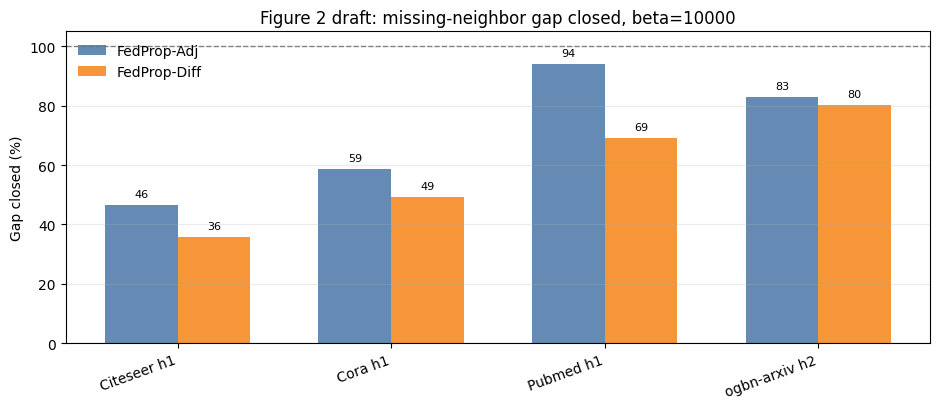

In [1]:
# Figure 2 — Missing-neighbor gap closed: numeric table + plot
from pathlib import Path
from IPython.display import display, HTML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
SUMMARY_DIR = REGISTRY / 'summaries'

summary_paths = [
    SUMMARY_DIR / 'planetoid_results_summary.csv',
    SUMMARY_DIR / 'large_scale_results_summary.csv',
]
summary = pd.concat([pd.read_csv(path) for path in summary_paths], ignore_index=True)
summary = summary[(summary['model'] == 'GCN') & (summary['PE'] == 'no')].copy()

fedprop_methods = ['FedProp-Adj', 'FedProp-Diff']
rows = []
for (dataset, hop, beta), group in summary.groupby(['dataset', 'hop', 'beta'], sort=False):
    zero = group[group['method'] == 'Zero-hop']
    full = group[group['method'] == 'Full-graph']
    if zero.empty or full.empty:
        for method in fedprop_methods:
            if not group[group['method'] == method].empty:
                rows.append({
                    'dataset': dataset, 'hop': hop, 'beta': beta, 'method': method,
                    'zero_acc': np.nan, 'full_acc': np.nan, 'fedprop_acc': group[group['method'] == method]['mean_acc_pct'].iloc[0],
                    'gap_closed_pct': np.nan, 'n_reps_min': int(group[group['method'] == method]['n_reps'].iloc[0]),
                    'status': '🔴 missing zero/full reference',
                    'note': 'Need matching Zero-hop and Full-graph rows for denominator.',
                })
        continue

    zero_acc = float(zero['mean_acc_pct'].iloc[0])
    full_acc = float(full['mean_acc_pct'].iloc[0])
    denom = full_acc - zero_acc
    for method in fedprop_methods:
        fed = group[group['method'] == method]
        if fed.empty:
            rows.append({
                'dataset': dataset, 'hop': hop, 'beta': beta, 'method': method,
                'zero_acc': zero_acc, 'full_acc': full_acc, 'fedprop_acc': np.nan,
                'gap_closed_pct': np.nan,
                'n_reps_min': int(min(zero['n_reps'].iloc[0], full['n_reps'].iloc[0])),
                'status': '🔴 missing FedProp row',
                'note': f'No {method} row for this dataset/hop/beta.',
            })
            continue
        fed_acc = float(fed['mean_acc_pct'].iloc[0])
        n_min = int(min(zero['n_reps'].iloc[0], full['n_reps'].iloc[0], fed['n_reps'].iloc[0]))
        if abs(denom) < 1e-9:
            gap = np.nan
            status = '🔴 zero denominator'
            note = 'Full-graph and Zero-hop have same mean accuracy.'
        else:
            gap = 100 * (fed_acc - zero_acc) / denom
            status = '🟢 complete' if n_min >= 10 else f'🟡 partial ({n_min} reps min)'
            note = 'Exceeds full-graph reference.' if gap > 100 else ('Below zero-hop reference.' if gap < 0 else '')
        rows.append({
            'dataset': dataset, 'hop': hop, 'beta': beta, 'method': method,
            'zero_acc': zero_acc, 'full_acc': full_acc, 'fedprop_acc': fed_acc,
            'gap_closed_pct': gap, 'n_reps_min': n_min, 'status': status, 'note': note,
        })

gap_df = pd.DataFrame(rows)
gap_df = gap_df.sort_values(['dataset', 'hop', 'beta', 'method']).reset_index(drop=True)

# Display a compact numeric table.
display_cols = ['dataset', 'hop', 'beta', 'method', 'zero_acc', 'fedprop_acc', 'full_acc', 'gap_closed_pct', 'n_reps_min', 'status', 'note']
formatted = gap_df[display_cols].copy()
for col in ['zero_acc', 'fedprop_acc', 'full_acc', 'gap_closed_pct']:
    formatted[col] = formatted[col].map(lambda x: '—' if pd.isna(x) else f'{x:.1f}')
formatted = formatted.rename(columns={
    'zero_acc': 'Zero-hop (%)',
    'fedprop_acc': 'FedProp (%)',
    'full_acc': 'Full-graph (%)',
    'gap_closed_pct': 'Gap closed (%)',
    'n_reps_min': 'min reps',
})

BG = {'🟢': '#d4edda', '🟡': '#fff3cd', '🔴': '#f8d7da'}
FG = {'🟢': '#155724', '🟡': '#7a5c00', '🔴': '#721c24'}

def _style_status(val):
    for icon, bg in BG.items():
        if str(val).startswith(icon):
            return f'background-color:{bg}; color:{FG[icon]}; font-weight:bold'
    return ''

styled = (
    formatted.style
    .map(_style_status, subset=['status'])
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('text-align', 'left'), ('padding', '6px 10px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('border-bottom', '1px solid #dee2e6')]},
    ])
    .hide(axis='index')
)

display(HTML(
    '<h4 style="margin-bottom:4px">Figure 2 — Missing-Neighbor Gap Closed</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px; margin-bottom:8px">'
    'Gap closed = (FedProp − Zero-hop) / (Full-graph − Zero-hop). '
    'Values above 100% mean FedProp exceeds the Full-graph reference for that matched setting.'
    '</p>'
    '<p style="color:#7a5c00; font-size:0.88em; background:#fff3cd; padding:6px 10px; border-radius:4px; margin-bottom:8px">'
    '<strong>Scope:</strong> PE=no only. Planetoid GCN 2-hop rows are prelim/partial; OGBN-Arxiv GCN 2-hop is complete. '
    'Rows require matching Zero-hop, Full-graph, and FedProp results.'
    '</p>'
))
display(styled)

# Plot a paper-friendly subset: IID beta=10000 with at least 3 matched repetitions.
# Smoke-only rows, such as Amazon Computers n=1, stay in the table but are not plotted.
plot_df = gap_df[(gap_df['beta'] == 10000) & gap_df['gap_closed_pct'].notna() & (gap_df['n_reps_min'] >= 3)].copy()
plot_df['label'] = plot_df['dataset'] + ' h' + plot_df['hop'].astype(str)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
labels = list(plot_df['label'].drop_duplicates())
methods = fedprop_methods
x = np.arange(len(labels))
width = 0.34
colors = {'FedProp-Adj': '#4c78a8', 'FedProp-Diff': '#f58518'}
for offset, method in zip([-width/2, width/2], methods):
    sub = plot_df[plot_df['method'] == method].set_index('label')
    values = [sub.loc[label, 'gap_closed_pct'] if label in sub.index else np.nan for label in labels]
    bars = ax.bar(x + offset, values, width=width, label=method, color=colors[method], alpha=0.86)
    for bar, val in zip(bars, values):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + (2 if val >= 0 else -5), f'{val:.0f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
ax.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.45)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.35)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Gap closed (%)')
ax.set_title('Figure 2 draft: missing-neighbor gap closed, beta=10000')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()



# 7.4 Backbone-Agnosticity: FedProp with GAT

## Purpose

This directly answers the objection that FedProp only works with GCN.

Core message:

> FedProp is a preprocessing/imputation framework, not a GCN-specific architecture.

## Table 3 — GAT backbone comparison

**Title:** Node classification accuracy under GAT backbone.

**Datasets:**

* Cora
* Citeseer
* Pubmed

**Methods:**

* Centralized GAT
* FedProp-GAT-Zero
* FedProp-GAT-Full / Oracle
* FedProp-GAT-Adj-L1
* FedProp-GAT-Diff-L1
* FedProp-GAT-Adj-L2
* FedProp-GAT-Diff-L2
* FedGAT

**Columns:**

* Dataset
* Regime: IID / non-IID
* Method
* Accuracy mean ± std
* Gap closed %, optional
* Extra neighbor communication, optional

Recommended format:

| Dataset | Regime | Centralized GAT | Zero | Full | FedProp-GAT-L1 | FedProp-GAT-L2 | FedGAT |
| ------- | ------ | --------------: | ---: | ---: | -------------: | -------------: | -----: |

**Caption draft:**

> GAT-backbone results on Cora, Citeseer, and Pubmed. FedProp-GAT applies the same local propagation procedure before training a GAT model. FedProp-GAT-L2 is compared directly with FedGAT under a matching backbone family.

## Text after Table 3

Paragraph 1:

> FedProp improves over the zero-hop GAT baseline, showing that the benefit is not restricted to GCN aggregation.

Paragraph 2:

> FedProp-GAT-L2 is the fairest comparison against FedGAT because both operate in a richer neighborhood-information regime.

Paragraph 3:

> These results support FedProp’s model-agnostic claim: the propagation module can be paired with different message-passing architectures.

---


,dataset,regime beta,Zero-hop,Full-graph,FedProp-Adj,FedProp-Diff,GAT L1,FedGAT
0,Cora,10000,61.2 ± 0.7 (n=10),81.0 ± 0.9 (n=10),74.5 ± 2.2 (n=10),70.2 ± 0.9 (n=10),— missing,— not run
1,Cora,10,61.5 ± 0.7 (n=10),81.0 ± 0.9 (n=10),74.8 ± 1.4 (n=10),70.2 ± 2.0 (n=10),— missing,— not run
2,Cora,1,67.2 ± 0.7 (n=10),81.4 ± 0.6 (n=10),80.2 ± 0.8 (n=10),76.9 ± 1.1 (n=10),— missing,— not run
3,Citeseer,10000,56.7 ± 2.1 (n=10),68.3 ± 0.9 (n=10),65.5 ± 1.7 (n=10),61.8 ± 1.8 (n=10),— missing,— not run
4,Citeseer,10,56.5 ± 0.7 (n=10),69.0 ± 0.9 (n=10),64.8 ± 1.8 (n=10),59.8 ± 3.7 (n=10),— missing,— not run
5,Citeseer,1,60.0 ± 0.8 (n=10),69.1 ± 1.0 (n=10),68.0 ± 1.0 (n=10),63.8 ± 1.8 (n=10),— missing,— not run
6,Pubmed,10000,64.3 ± 0.9 (n=10),78.6 ± 0.4 (n=10),79.4 ± 0.6 (n=10),75.6 ± 1.2 (n=10),— missing,— not run
7,Pubmed,10,67.5 ± 0.5 (n=10),78.9 ± 1.2 (n=10),77.3 ± 0.9 (n=10),75.6 ± 0.9 (n=10),— missing,— not run
8,Pubmed,1,64.0 ± 2.4 (n=10),70.7 ± 1.0 (n=10),71.9 ± 0.4 (n=10),71.3 ± 2.4 (n=10),— missing,— not run


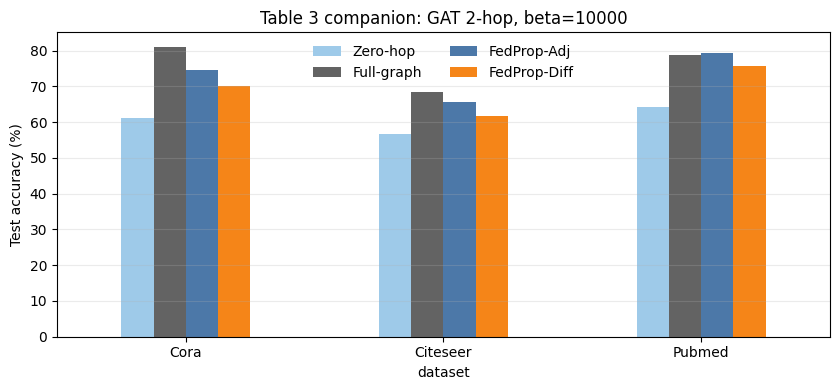

In [1]:
# Table 3 — GAT backbone: populated where available, gaps shown explicitly
from pathlib import Path
from IPython.display import display, HTML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
plan = pd.read_csv(REGISTRY / 'summaries/planetoid_results_summary.csv')
gat = plan[(plan['model'] == 'GAT') & (plan['hop'] == 2) & (plan['PE'] == 'no')].copy()
methods = ['Zero-hop', 'Full-graph', 'FedProp-Adj', 'FedProp-Diff']
rows = []
for dataset in ['Cora', 'Citeseer', 'Pubmed']:
    for beta in [10000, 10, 1]:
        row = {'dataset': dataset, 'regime beta': beta, 'GAT L1': '— missing', 'FedGAT': '— not run'}
        sub = gat[(gat['dataset'] == dataset) & (gat['beta'] == beta)]
        for method in methods:
            m = sub[sub['method'] == method]
            row[method] = '—' if m.empty else f"{m['mean_acc_pct'].iloc[0]:.1f} ± {m['std_acc_pct'].iloc[0]:.1f} (n={int(m['n_reps'].iloc[0])})"
        rows.append(row)

table = pd.DataFrame(rows)[['dataset', 'regime beta', 'Zero-hop', 'Full-graph', 'FedProp-Adj', 'FedProp-Diff', 'GAT L1', 'FedGAT']]

display(HTML(
    '<h4 style="margin-bottom:4px">Table 3 — GAT Backbone Results</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px">GAT 2-hop is complete for Planetoid. GAT 1-hop and FedGAT were not run, so those columns stay blank/TBD.</p>'
))
display(table)

plot_df = gat[(gat['beta'] == 10000) & (gat['method'].isin(methods))].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.0))
pivot = plot_df.pivot(index='dataset', columns='method', values='mean_acc_pct').reindex(['Cora', 'Citeseer', 'Pubmed'])
pivot[methods].plot(kind='bar', ax=ax, color=['#9ecae9', '#636363', '#4c78a8', '#f58518'])
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Table 3 companion: GAT 2-hop, beta=10000')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



# 7.5 Heterophilic Graphs and Smoothness Limits

## Purpose

This addresses the reviewer concern about the Dirichlet/smoothness assumption.

Core message:

> FedProp is expected to be less reliable on heterophilic graphs, and the results should be interpreted as a limitation analysis.

## Table 4 — Heterophilic dataset results

If Texas/Wisconsin are not already included in Table 2, use a separate table here.

**Title:** FedProp on heterophilic graphs.

**Datasets:**

* Texas
* Wisconsin

**Methods:**

* Centralized GCN
* FedProp-Zero
* FedProp-Full
* FedProp-Adj-L1
* FedProp-Diff-L1
* FedProp-Adj-L2, if available
* FedProp-Diff-L2, if available
* FedGCN, if available

**Columns:**

* Dataset
* Homophily ratio
* Partition regime
* Zero-hop accuracy
* FedProp accuracy
* Oracle/full accuracy
* Gain over zero-hop
* Gap closed %

Recommended format:

| Dataset | Homophily | Regime | Zero | Full | FedProp-Adj | FedProp-Diff | Gain over Zero |
| ------- | --------: | ------ | ---: | ---: | ----------: | -----------: | -------------: |

**Caption draft:**

> Results on heterophilic graphs. Since FedProp is based on smoothness-guided propagation, heterophilic graphs test a natural limitation of the method. Gains are expected to be smaller or less stable when connected nodes do not have similar features.

## Optional Figure 3 — Homophily vs gain

If you have enough data:

**X-axis:** dataset homophily
**Y-axis:** FedProp gain over zero-hop or recovery ratio
**Points:** Cora, Citeseer, Pubmed, OGBN-Arxiv, Texas, Wisconsin.

This would be a very strong interpretive figure.

**Caption draft:**

> Relationship between graph homophily and FedProp improvement over zero-hop. The trend illustrates that smoothness-based imputation is more effective when connected nodes have similar feature-label structure.

## Text after Table 4

Paragraph 1:

> The heterophilic datasets test the failure mode predicted by the theory: if neighboring nodes are dissimilar, smooth feature propagation can introduce bias rather than recover missing information.

Paragraph 2:

> The results show smaller and less consistent gains than on homophilic citation graphs. This supports the interpretation that FedProp is best suited to settings where feature smoothness is a reasonable inductive bias.

Paragraph 3:

> These results should not be read as a failure of implementation; they identify the boundary of the method’s assumptions.

---


method,dataset,beta,FedProp-Adj,FedProp-Diff,Zero-hop
0,Texas,10000,74.1 ± 5.8 (n=5),73.5 ± 6.3 (n=5),69.7 ± 4.3 (n=5)
1,Wisconsin,10000,74.1 ± 2.6 (n=5),78.8 ± 4.9 (n=5),77.3 ± 4.4 (n=5)


,result_key,configs,repetitions,status,notes
24,chameleon_gcn_1-hop,0,0/10,missing source,No source folder found
25,chameleon_gcn_2-hop,0,0/10,missing source,No source folder found
26,chameleon_gat_1-hop,0,0/10,missing source,No source folder found
27,chameleon_gat_2-hop,0,0/10,missing source,No source folder found
28,squirrel_gcn_1-hop,0,0/10,missing source,No source folder found
29,squirrel_gcn_2-hop,0,0/10,missing source,No source folder found
30,squirrel_gat_1-hop,0,0/10,missing source,No source folder found
31,squirrel_gat_2-hop,0,0/10,missing source,No source folder found
32,texas_gcn_1-hop,3/12,15/120,partial,Zero-hop PE=no beta=10; Zero-hop PE=no beta=1;...
33,texas_gcn_2-hop,0,0/10,missing source,No source folder found


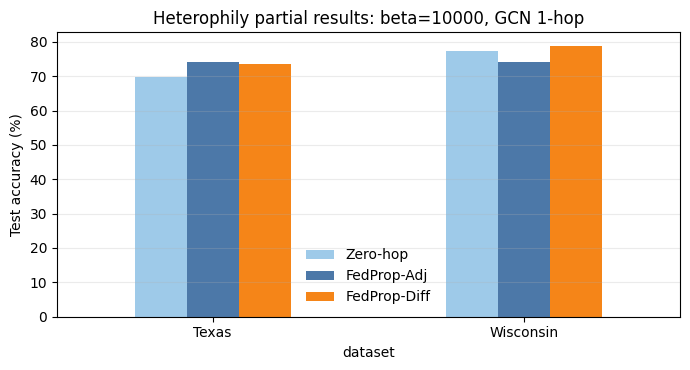

In [2]:
# Table 4 — Heterophilic graphs: partial Phase 6 evidence + missing matrix
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
het = pd.read_csv(REGISTRY / 'summaries/heterophily_results_summary.csv')
status = pd.read_csv(REGISTRY / 'inventory/current_result_inventory.csv')
het_status = status[status['result_key'].str.contains('texas|wisconsin|chameleon|squirrel', case=False, regex=True)].copy()

main = het[het['method'].isin(['Zero-hop', 'FedProp-Adj', 'FedProp-Diff'])].copy()
main['accuracy'] = main.apply(lambda r: f"{r['mean_acc_pct']:.1f} ± {r['std_acc_pct']:.1f} (n={int(r['n_reps'])})", axis=1)
table = main.pivot_table(index=['dataset', 'beta'], columns='method', values='accuracy', aggfunc='first').reset_index()

display(HTML(
    '<h4 style="margin-bottom:4px">Table 4 — Heterophilic Graphs</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px">Only Texas/Wisconsin GCN 1-hop beta=10000 has recovered data. These are Phase 6 overlap results, not full top-level R6.</p>'
))
display(table)

display(HTML('<h4 style="margin-bottom:4px">Heterophily Coverage Matrix</h4>'))
display(het_status[['result_key', 'configs', 'repetitions', 'status', 'notes']])

fig, ax = plt.subplots(figsize=(7.0, 3.8))
plot_df = main.pivot(index='dataset', columns='method', values='mean_acc_pct').reindex(['Texas', 'Wisconsin'])
plot_df[['Zero-hop', 'FedProp-Adj', 'FedProp-Diff']].plot(kind='bar', ax=ax, color=['#9ecae9', '#4c78a8', '#f58518'])
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Heterophily partial results: beta=10000, GCN 1-hop')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



# 7.6 Cross-Family Baseline Positioning: FedSage+, FedDEP, and FedCog

## Purpose

This addresses the “missing baselines” and “FedCog similarity” objections without contaminating the main same-protocol tables.

Core message:

> FedSage+, FedDEP, and FedCog are relevant but use different protocols or communication models. They should be compared carefully.

## Table 5 — Protocol and communication comparison

**Title:** Comparison with generative and coupled-graph federated baselines.

**Columns:**

* Method
* Problem setting
* Partition protocol
* Split protocol
* Backbone
* Handles missing neighbors by
* Requires generator?
* Shares raw features?
* Shares embeddings?
* Shares border-node information?
* Per-round extra communication?
* Same protocol as FedProp/FedGCN?
* Included in main accuracy table?

**Rows:**

* FedProp-L1
* FedProp-L2
* FedGCN
* FedGAT
* FedSage+
* FedDEP
* FedCog
* OpenFGL-related methods, optional

**Caption draft:**

> Protocol-level comparison with related federated graph learning methods. FedSage+ and FedDEP are designed for missing-neighbor generation but are typically evaluated under different partition and split protocols. FedCog addresses coupled graphs through border-embedding exchange, whereas FedProp performs local imputation without per-round border embedding communication.

## Optional Table 6 — Cross-protocol numerical comparison

Only include if you have FedSage+/FedDEP results or literature numbers you can clearly label.

**Title:** Indicative comparison to generative baselines under native protocols.

**Columns:**

* Method
* Dataset
* Protocol
* Accuracy
* Communication type
* Directly comparable? yes/no

**Important table note:**

> These results are indicative only and are not used for same-protocol ranking.

## Text after Table 5

Paragraph 1:

> We do not mix FedSage+ and FedDEP into the main accuracy table unless they are reproduced under the same Dirichlet/transductive protocol, because their native evaluation uses different splits and partitioning assumptions.

Paragraph 2:

> FedCog is the closest conceptual comparison because it also addresses cross-client graph structure. The key difference is that FedCog communicates border embeddings between clients, while FedProp performs imputation locally.

Paragraph 3:

> Thus, FedProp occupies a distinct point in the design space: no generator, no feature exchange, no hidden embedding exchange, and no per-round border-node communication.

---


In [3]:
# Table 5 — Cross-family baseline positioning: literature-only / not run in this codebase
from IPython.display import display, HTML
import pandas as pd

rows = [
    ('FedProp', 'ours', '🟢 have', 'Registry summaries', 'Zero-hop, Full-graph, FedProp-Adj, FedProp-Diff available across several sections.'),
    ('FedGCN', 'neighbor feature exchange baseline', '🔴 not run', '—', 'Needed for direct communication/accuracy comparison.'),
    ('FedGAT', 'attention backbone baseline', '🔴 not run', '—', 'GAT 2-hop FedProp exists; FedGAT baseline does not.'),
    ('FedSage+', 'generator / missing-neighbor synthesis', '⚪ literature only', 'manual citation required', 'Different partition/split protocol; not directly comparable from current registry.'),
    ('FedDEP', 'generator / dependency modeling', '⚪ literature only', 'manual citation required', 'No local runs; use only as cited context.'),
    ('FedCog', 'border embedding / cross-client protocol', '⚪ literature only', 'manual citation required', 'Protocol differs; no local runs.'),
]
df = pd.DataFrame(rows, columns=['method family', 'role', 'data status', 'source', 'notebook action'])
BG = {'🟢': '#d4edda', '🔴': '#f8d7da', '⚪': '#e9ecef'}
FG = {'🟢': '#155724', '🔴': '#721c24', '⚪': '#495057'}
def style_status(v):
    for icon, bg in BG.items():
        if str(v).startswith(icon):
            return f'background-color:{bg}; color:{FG[icon]}; font-weight:bold'
    return ''

display(HTML(
    '<h4 style="margin-bottom:4px">Table 5 — Cross-Family Baseline Positioning</h4>'
    '<p style="color:#721c24; font-size:0.88em; background:#f8d7da; padding:6px 10px; border-radius:4px">No FedSage+/FedDEP/FedCog runs exist in this codebase. This section should be framed as literature positioning unless numbers are manually imported with citations.</p>'
))
display(df.style.map(style_status, subset=['data status']).hide(axis='index').set_properties(**{'text-align':'left'}))


method family,role,data status,source,notebook action
FedProp,ours,🟢 have,Registry summaries,"Zero-hop, Full-graph, FedProp-Adj, FedProp-Diff available across several sections."
FedGCN,neighbor feature exchange baseline,🔴 not run,—,Needed for direct communication/accuracy comparison.
FedGAT,attention backbone baseline,🔴 not run,—,GAT 2-hop FedProp exists; FedGAT baseline does not.
FedSage+,generator / missing-neighbor synthesis,⚪ literature only,manual citation required,Different partition/split protocol; not directly comparable from current registry.
FedDEP,generator / dependency modeling,⚪ literature only,manual citation required,No local runs; use only as cited context.
FedCog,border embedding / cross-client protocol,⚪ literature only,manual citation required,Protocol differs; no local runs.


# 7.7 Robustness to Partition Severity

## Purpose

This explains IID vs non-IID behavior more fully than a two-column table can.

Core message:

> As partitions become more non-IID, the boundary signal weakens and propagation becomes harder, but FedProp remains useful relative to zero-hop.

## Figure 4 — β sweep

**Title:** Effect of partition non-IIDness on FedProp performance.

**Dataset:**

* Cora primary
* Pubmed optional

**X-axis:**

* β = 10000, 100, 10, 1

**Y-axis:**

* Test accuracy

**Lines:**

* FedProp-Zero
* FedProp-L1
* FedProp-L2
* FedProp-Full
* FedGCN

**Caption draft:**

> Effect of Dirichlet partition severity on test accuracy. Smaller β corresponds to stronger label skew and more challenging client partitions. FedProp remains above the zero-hop baseline, although the benefit varies with partition severity.

## Text after Figure 4

Paragraph 1:

> Non-IID partitioning affects FedProp through two mechanisms: it changes the local label distribution and increases the difficulty of reconstructing remote-neighbor features from local boundary information.

Paragraph 2:

> The β sweep shows whether degradation is gradual or abrupt, and whether FedProp-L2 remains closer to the oracle than zero-hop as heterogeneity increases.

Paragraph 3:

> This experiment supports the claim that FedProp is robust to partition variation, but not invariant to it.

---


,method,beta,n_reps,mean_acc_pct,std_acc_pct
8,FedProp-Adj,1,10,76.5600,1.468469
7,FedProp-Adj,10,10,73.3600,1.221638
6,FedProp-Adj,10000,10,71.6100,1.665803
10,FedProp-Diff,10,8,71.2875,1.310951
9,FedProp-Diff,10000,10,69.6800,1.676783
5,Full-graph,1,10,81.1200,0.501597
4,Full-graph,10,10,80.1900,0.631585
3,Full-graph,10000,10,79.9300,0.654294
2,Zero-hop,1,10,65.7200,2.684697
1,Zero-hop,10,10,61.5800,2.217566


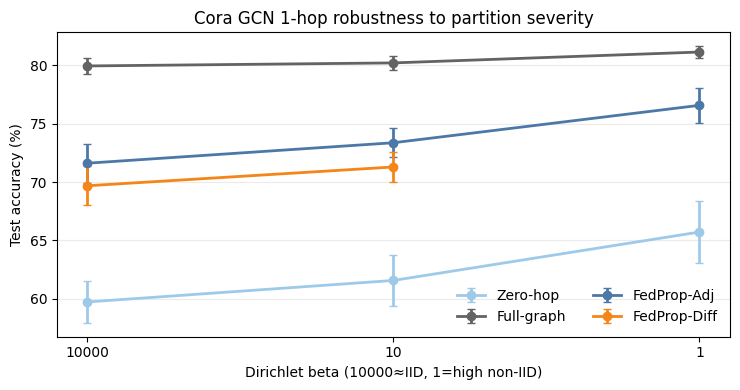

In [4]:
# Figure 4 — Beta sweep: Cora GCN 1-hop, real registry data
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
plan = pd.read_csv(REGISTRY / 'summaries/planetoid_results_summary.csv')
cora = plan[(plan['dataset'] == 'Cora') & (plan['model'] == 'GCN') & (plan['hop'] == 1) & (plan['PE'] == 'no')].copy()
methods = ['Zero-hop', 'Full-graph', 'FedProp-Adj', 'FedProp-Diff']
cora = cora[cora['method'].isin(methods)]

display(HTML(
    '<h4 style="margin-bottom:4px">Figure 4 — Partition Severity / β Sweep</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px">Cora GCN 1-hop has beta ∈ {10000, 10, 1}; most rows have 10 repetitions, with one FedProp-Diff beta=10 partial row.</p>'
))
display(cora[['method', 'beta', 'n_reps', 'mean_acc_pct', 'std_acc_pct']].sort_values(['method', 'beta']))

fig, ax = plt.subplots(figsize=(7.5, 4.0))
for method, color in zip(methods, ['#9ecae9', '#636363', '#4c78a8', '#f58518']):
    sub = cora[cora['method'] == method].sort_values('beta', ascending=False)
    ax.errorbar(sub['beta'].astype(str), sub['mean_acc_pct'], yerr=sub['std_acc_pct'], marker='o', linewidth=2, capsize=3, label=method, color=color)
ax.set_xlabel('Dirichlet beta (10000≈IID, 1=high non-IID)')
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Cora GCN 1-hop robustness to partition severity')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()



# 7.8 Scalability with Client Count

## Purpose

This addresses client fragmentation and scalability.

Core message:

> FedProp remains useful as the graph is split across more clients.

## Figure 5 — Client-count scaling

**Title:** Accuracy as the number of clients increases.

**Dataset:**

* Cora

**X-axis:**

* K = 1, 5, 10, 20

**Y-axis:**

* Test accuracy

**Panels:**

* IID
* non-IID

**Lines:**

* FedProp-Zero
* FedProp-L1
* FedProp-L2
* FedGCN
* FedProp-Full, optional

**Caption draft:**

> Client-count scaling on Cora. As K increases, graph fragmentation increases and more edges cross client boundaries. FedProp mitigates the resulting degradation relative to zero-hop training.

## Optional Figure 6 — Communication cost vs number of clients

**X-axis:** number of clients
**Y-axis:** communication cost
**Lines:**

* FedProp
* FedGCN
* FedGAT

**Caption draft:**

> Communication cost as the number of clients increases. FedProp maintains the FedAvg communication profile during training, while transmission-based methods incur additional cost for neighborhood information exchange.

## Text after Figure 5

Paragraph 1:

> Increasing the number of clients increases the number of partition boundaries and therefore the missing-neighbor burden.

Paragraph 2:

> FedProp remains above zero-hop across client counts, showing that local propagation continues to provide useful information under increasing fragmentation.

Paragraph 3:

> The communication panel highlights why this matters: FedProp does not introduce additional feature-exchange cost as K grows.

---


,method,beta,clients,hop,n_reps,mean_acc_pct,std_acc_pct
17,FedProp-Adj,1,1,1,5,80.72,0.248193
19,FedProp-Adj,1,2,1,5,80.50,1.108152
20,FedProp-Adj,1,4,1,5,80.26,0.893532
21,FedProp-Adj,1,6,1,5,78.78,1.800444
22,FedProp-Adj,1,8,1,5,77.20,0.792465
...,...,...,...,...,...,...,...
68,Zero-hop,10000,12,1,5,60.54,1.254751
69,Zero-hop,10000,14,1,5,59.22,1.713943
70,Zero-hop,10000,16,1,5,58.34,2.987039
71,Zero-hop,10000,18,1,5,57.62,2.406159


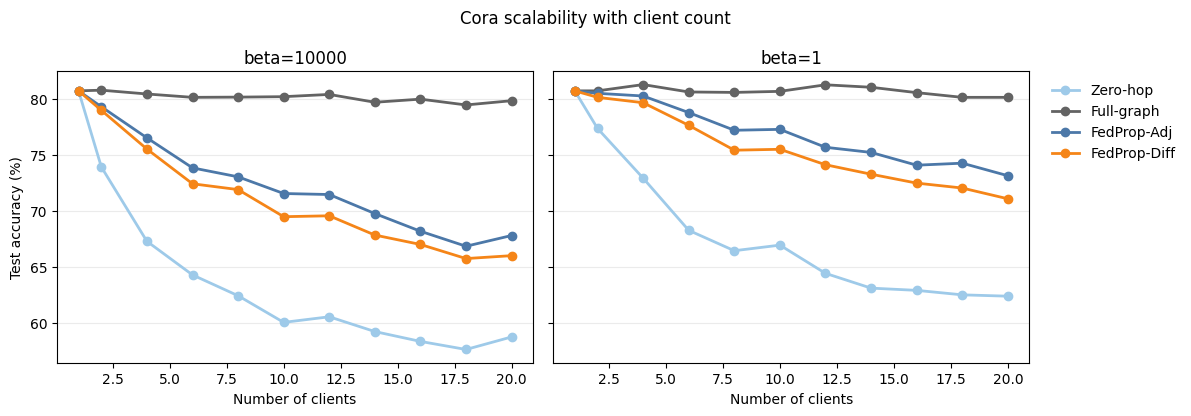

In [5]:
# Figure 5 — Client scaling: R5 Cora scalability results
from pathlib import Path
from IPython.display import display, HTML
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

R5 = Path('/home/bosho/FP/experiments/all_results/R5_Cora_scalability')
if not R5.exists():
    R5 = Path('/home/bosho/FP/experiments/results/R5')

rows = []
for path in sorted(R5.glob('**/results_*.json')):
    try:
        data = json.loads(path.read_text())
    except Exception:
        continue
    cfg = data.get('experiment_config', {})
    vals = data.get('summary', {}).get('global_results', [])
    vals = [float(v) for v in vals if isinstance(v, (int, float)) and np.isfinite(float(v))]
    if not vals:
        continue
    rows.append({
        'dataset': cfg.get('dataset'),
        'method': {'zero_hop': 'Zero-hop', 'full': 'Full-graph', 'adjacency': 'FedProp-Adj', 'diffusion': 'FedProp-Diff'}.get(cfg.get('data_loading_option'), cfg.get('data_loading_option')),
        'propagation': cfg.get('data_loading_option'),
        'beta': int(float(cfg.get('beta'))),
        'clients': int(cfg.get('num_clients')),
        'hop': int(cfg.get('hop')),
        'n_reps': len(vals),
        'mean_acc_pct': 100 * float(np.mean(vals)),
        'std_acc_pct': 100 * float(np.std(vals)),
        'source': str(path.relative_to('/home/bosho/FP')),
    })
scale = pd.DataFrame(rows).drop_duplicates(['method', 'beta', 'clients', 'hop'], keep='last')
scale = scale.sort_values(['beta', 'method', 'clients'])

display(HTML(
    '<h4 style="margin-bottom:4px">Figure 5 — Client Scaling</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px">Recovered from R5 Cora scalability JSON files. Each point aggregates the repetitions stored in that result JSON.</p>'
))
display(scale[['method', 'beta', 'clients', 'hop', 'n_reps', 'mean_acc_pct', 'std_acc_pct']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
methods = ['Zero-hop', 'Full-graph', 'FedProp-Adj', 'FedProp-Diff']
colors = {'Zero-hop': '#9ecae9', 'Full-graph': '#636363', 'FedProp-Adj': '#4c78a8', 'FedProp-Diff': '#f58518'}
for ax, beta in zip(axes, [10000, 1]):
    sub_beta = scale[scale['beta'] == beta]
    for method in methods:
        sub = sub_beta[sub_beta['method'] == method].sort_values('clients')
        if sub.empty:
            continue
        ax.plot(sub['clients'], sub['mean_acc_pct'], marker='o', linewidth=2, label=method, color=colors[method])
    ax.set_title(f'beta={beta}')
    ax.set_xlabel('Number of clients')
    ax.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('Test accuracy (%)')
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.suptitle('Cora scalability with client count')
plt.tight_layout()
plt.show()


# 7.9 Propagation Depth and Operator Ablations

## Purpose

This is optional in main but useful if you do not care about page limits now.

Core message:

> The chosen propagation configuration is not arbitrary; performance saturates around the selected number of iterations, and operator choice matters.

## Figure 7 — Propagation iteration sensitivity

**Title:** Sensitivity to propagation iterations.

**Datasets:**

* Cora
* Pubmed
* OGBN-Arxiv, optional

**X-axis:**

* T = 10, 25, 50, 100

**Y-axis:**

* Accuracy
* or reconstruction error if available

**Lines:**

* FedProp-Adj
* FedProp-Diff

**Caption draft:**

> Effect of propagation depth on accuracy. Performance improves initially and then saturates, supporting the use of T=50 in the main experiments.

## Table 6 — Operator and PE ablation

**Title:** Ablation over propagation operator and positional encoding.

**Datasets:**

* Cora
* Citeseer
* Pubmed
* OGBN-Arxiv, optional

**Methods:**

* Adj
* Adj+PE
* Diff
* Diff+PE
* Chebyshev, optional
* APPNP, optional
* Random Walk, optional

**Columns:**

* Dataset
* Regime
* Operator
* L1 accuracy
* L2 accuracy
* with PE
* without PE

**Caption draft:**

> Operator and positional encoding ablation. The main experiments use the strongest stable FedProp variant for each setting, while this table reports the full comparison across propagation operators and PE variants.

---


,dataset,model,hop,method,n_reps,mean_acc_pct,std_acc_pct
43,Citeseer,GCN,1,FedProp-Adj,10,63.800000,1.463557
46,Citeseer,GCN,1,FedProp-Diff,10,62.620000,1.456571
40,Citeseer,GCN,1,Full-graph,10,69.720000,0.365513
37,Citeseer,GCN,1,Zero-hop,10,58.660000,1.490101
50,Citeseer,GCN,2,FedProp-Adj,3,65.833333,0.449691
54,Citeseer,GCN,2,FedProp-Diff,3,66.900000,0.141421
48,Citeseer,GCN,2,Full-graph,6,69.733333,0.430762
128,Computers,GCN,2,FedProp-Adj,1,37.800000,0.000000
127,Computers,GCN,2,Full-graph,1,37.800000,0.000000
126,Computers,GCN,2,Zero-hop,1,37.100000,0.000000


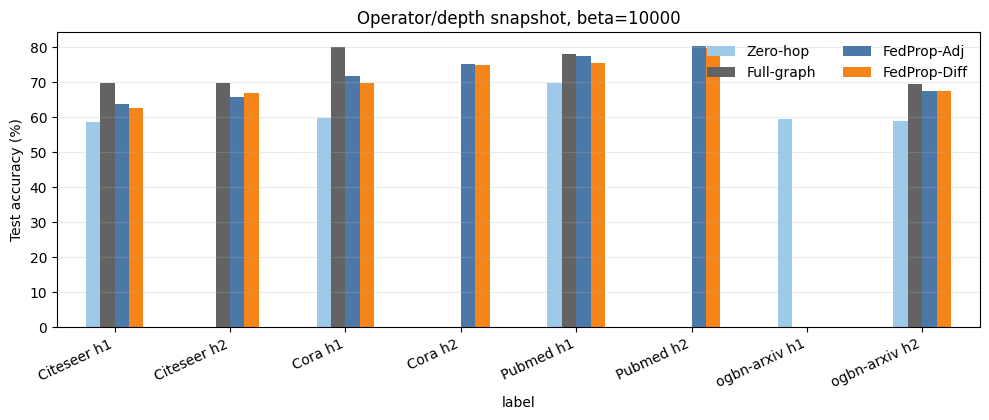

In [6]:
# 7.9 — Propagation depth and operator ablations: what can be populated
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
plan = pd.read_csv(REGISTRY / 'summaries/planetoid_results_summary.csv')
large = pd.read_csv(REGISTRY / 'summaries/large_scale_results_summary.csv')
all_df = pd.concat([plan, large], ignore_index=True)

ab = all_df[(all_df['model'] == 'GCN') & (all_df['PE'] == 'no') & (all_df['method'].isin(['Zero-hop', 'Full-graph', 'FedProp-Adj', 'FedProp-Diff']))].copy()
# Focus on beta=10000 where all compared settings are easiest to read.
ab10000 = ab[ab['beta'] == 10000].copy()

display(HTML(
    '<h4 style="margin-bottom:4px">7.9 — Depth / Operator Ablation Status</h4>'
    '<p style="color:#555; font-size:0.88em; margin-top:2px">Numeric rows are shown for beta=10000. Planetoid hop-2 is prelim/partial; OGBN-Arxiv GCN hop-2 is complete.</p>'
))
display(ab10000[['dataset', 'model', 'hop', 'method', 'n_reps', 'mean_acc_pct', 'std_acc_pct']].sort_values(['dataset', 'hop', 'method']))

plot_df = ab10000[ab10000['dataset'].isin(['Cora', 'Citeseer', 'Pubmed', 'ogbn-arxiv'])]
fig, ax = plt.subplots(figsize=(10, 4.3))
plot_df['label'] = plot_df['dataset'] + ' h' + plot_df['hop'].astype(str)
pivot = plot_df.pivot_table(index='label', columns='method', values='mean_acc_pct', aggfunc='first')
pivot[['Zero-hop', 'Full-graph', 'FedProp-Adj', 'FedProp-Diff']].plot(kind='bar', ax=ax, color=['#9ecae9', '#636363', '#4c78a8', '#f58518'])
ax.set_ylabel('Test accuracy (%)')
ax.set_title('Operator/depth snapshot, beta=10000')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False, ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


# 7.10 Extended Dataset Results: Amazon Computers and Amazon Photos

## Purpose

This broadens the empirical scope beyond citation graphs.

Core message:

> FedProp is not limited to Planetoid citation networks.

## Table 7 — Amazon dataset results

**Title:** Extended validation on Amazon co-purchase graphs.

**Datasets:**

* Amazon Computers
* Amazon Photos

**Methods:**

* Centralized GCN
* FedProp-Zero
* FedProp-Full
* FedProp-L1
* FedProp-L2
* FedGCN, if available

Optional GAT block:

* Centralized GAT
* FedProp-GAT-Zero
* FedProp-GAT-L2

**Columns:**

* Dataset
* Regime
* Method
* Accuracy mean ± std
* Gap closed %

**Caption draft:**

> Extended results on Amazon co-purchase graphs. These datasets provide denser homophilic graphs beyond the standard citation benchmarks.

## Text after Table 7

Paragraph 1:

> Amazon Computers and Amazon Photos test FedProp under denser graph regimes.

Paragraph 2:

> The results indicate whether local propagation remains effective when average degree and graph density are substantially higher than in Planetoid datasets.

---


,result_key,configs,repetitions,status,notes
16,amazon-photo_gcn_1-hop,0,0/10,missing source,"Config/path found, but no usable result datapo..."
17,amazon-photo_gcn_2-hop,0,0/10,missing source,"Config/path found, but no usable result datapo..."
18,amazon-photo_gat_1-hop,0,0/10,missing source,No source folder found
19,amazon-photo_gat_2-hop,0,0/10,missing source,No source folder found
20,amazon-computers_gcn_1-hop,0,0/10,missing source,"Config/path found, but no usable result datapo..."
21,amazon-computers_gcn_2-hop,3/3,3/30,partial,Zero-hop PE=no beta=10000: 1/10; Full-graph PE...
22,amazon-computers_gat_1-hop,0,0/10,missing source,No source folder found
23,amazon-computers_gat_2-hop,0,0/10,missing source,No source folder found


,dataset,model,hop,method,beta,n_reps,mean_acc_pct,std_acc_pct
13,Computers,GCN,2,Zero-hop,10000,1,37.1,0.0
14,Computers,GCN,2,Full-graph,10000,1,37.8,0.0
15,Computers,GCN,2,FedProp-Adj,10000,1,37.8,0.0


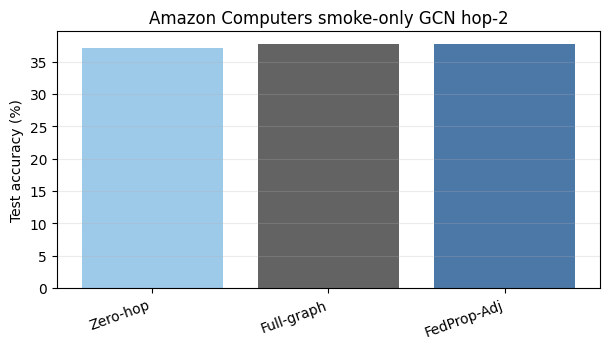

In [7]:
# 7.10 — Amazon Computers and Amazon Photo: status + smoke-only numbers
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd
import matplotlib.pyplot as plt

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
large = pd.read_csv(REGISTRY / 'summaries/large_scale_results_summary.csv')
inv = pd.read_csv(REGISTRY / 'inventory/current_result_inventory.csv')
amz_status = inv[inv['result_key'].str.startswith('amazon-')].copy()
amz_data = large[large['dataset'].isin(['Photo', 'Computers'])].copy()

display(HTML(
    '<h4 style="margin-bottom:4px">Table 7 — Amazon Results</h4>'
    '<p style="color:#721c24; font-size:0.88em; background:#f8d7da; padding:6px 10px; border-radius:4px">Amazon Photo has configs but no usable datapoints. Amazon Computers has smoke-only GCN hop-2 datapoints, not a full result table.</p>'
))
display(amz_status[['result_key', 'configs', 'repetitions', 'status', 'notes']])

if amz_data.empty:
    display(pd.DataFrame([{'message': 'No Amazon datapoints recovered.'}]))
else:
    display(amz_data[['dataset', 'model', 'hop', 'method', 'beta', 'n_reps', 'mean_acc_pct', 'std_acc_pct']])
    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    sub = amz_data[(amz_data['dataset'] == 'Computers') & (amz_data['hop'] == 2)]
    ax.bar(sub['method'], sub['mean_acc_pct'], color=['#9ecae9', '#636363', '#4c78a8'][:len(sub)])
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title('Amazon Computers smoke-only GCN hop-2')
    ax.grid(axis='y', alpha=0.25)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()


# 7.11 Summary of Findings

## Purpose

Close the results section by tying every result back to the paper’s claims.

## Text-only summary

Suggested paragraph:

> The results support five conclusions. First, FedProp’s primary advantage is its communication–accuracy tradeoff: it improves substantially over zero-hop training while avoiding feature or embedding exchange during federated training. Second, FedProp-L2 is competitive with neighborhood-aware baselines such as FedGCN and FedGAT under a comparable relaxed topology setting. Third, FedProp-L1 establishes the stricter local-information regime and still improves over zero-hop training. Fourth, GAT experiments show that FedProp is not tied to a GCN backbone. Fifth, heterophilic datasets expose the expected limitation of smoothness-based imputation, where gains become smaller and less stable. Finally, client-scaling results show that FedProp remains useful as graph fragmentation increases.

---


In [8]:
# 7.11 — Summary of findings: generated from registry status
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd

REGISTRY = Path('/home/bosho/FP/experiments/output/result_registry')
inv = pd.read_csv(REGISTRY / 'inventory/current_result_inventory.csv')
counts = inv['status'].value_counts().rename_axis('status').reset_index(name='count')
complete = inv[inv['status'] == 'complete']['result_key'].tolist()
partial = inv[inv['status'] == 'partial']['result_key'].tolist()

finding_rows = [
    ('Main positive result', 'FedProp improves over Zero-hop in the populated GCN/GAT settings.', 'Supported by Table 2, Figure 2, Table 3.'),
    ('Best complete blocks', ', '.join(complete), 'These are safest for paper tables.'),
    ('Partial but useful', 'Planetoid GCN L1/L2, heterophily Texas/Wisconsin, Amazon Computers smoke.', 'Use with visible n and caveats.'),
    ('Missing baselines', 'FedGCN, FedGAT, FedSage+, FedDEP, FedCog.', 'Leave blank/TBD or literature-only.'),
    ('Most urgent runs', 'FedGCN/FedGAT baselines; complete heterophily/R7 Amazon if those sections matter.', 'Driven by inventory gaps.'),
]
findings = pd.DataFrame(finding_rows, columns=['finding', 'claim', 'evidence / action'])

display(HTML('<h4 style="margin-bottom:4px">7.11 — Generated Summary of Findings</h4>'))
display(counts)
display(findings)


,status,count
0,missing source,26
1,partial,10
2,complete,4


,finding,claim,evidence / action
0,Main positive result,FedProp improves over Zero-hop in the populate...,"Supported by Table 2, Figure 2, Table 3."
1,Best complete blocks,"cora_gat_2-hop, citeseer_gat_2-hop, pubmed_gat...",These are safest for paper tables.
2,Partial but useful,"Planetoid GCN L1/L2, heterophily Texas/Wiscons...",Use with visible n and caveats.
3,Missing baselines,"FedGCN, FedGAT, FedSage+, FedDEP, FedCog.",Leave blank/TBD or literature-only.
4,Most urgent runs,FedGCN/FedGAT baselines; complete heterophily/...,Driven by inventory gaps.



# Appendix Structure

Since you said not to worry about page limits, here is the full appendix structure too.

## Appendix A — Full L1 vs L2 Results

**Table A1:** Full L1 vs L2 results on Cora, Citeseer, Pubmed.

Rows:

* Adj-L1
* Diff-L1
* Adj-L2
* Diff-L2
* Adj+PE-L1
* Diff+PE-L1
* Adj+PE-L2
* Diff+PE-L2

Columns:

* IID accuracy
* non-IID accuracy
* gap closed %

---

## Appendix B — Full GAT Tables

**Table A2:** GAT IID results.
**Table A3:** GAT non-IID results.

Include all GAT variants:

* Zero
* Full
* Adj-L1
* Diff-L1
* Adj-L2
* Diff-L2
* FedGAT

---

## Appendix C — β Sweep Details

**Figure A1:** β sweep on Cora.
**Figure A2:** β sweep on Pubmed, optional.
**Table A4:** Full β sweep numerical values.

---

## Appendix D — PE Ablation

**Table A5:** PE vs no PE for GCN.
**Table A6:** PE vs no PE for GAT.
**Figure A3:** PE effect by dataset.

---

## Appendix E — Propagation Iteration Sensitivity

**Figure A4:** Accuracy vs T.
**Figure A5:** Dirichlet residual vs iteration.
**Table A7:** Best T per dataset.

---

## Appendix F — Amazon Extended Results

**Table A8:** Amazon Computers.
**Table A9:** Amazon Photos.

Include:

* GCN primary
* GAT if available
* L1/L2 if available
* PE/no PE if available

---

## Appendix G — Cross-Protocol Baseline Details

**Table A10:** FedSage+, FedDEP, FedCog protocol comparison.

Columns:

* method
* split protocol
* partition protocol
* client count
* communication type
* generator?
* feature exchange?
* embedding exchange?
* comparable to main table?

---

## Appendix H — Hyperparameters and Reproducibility

**Table A11:** Dataset statistics.
**Table A12:** GCN hyperparameters.
**Table A13:** GAT hyperparameters.
**Table A14:** Federated training settings.
**Table A15:** Propagation settings.
**Table A16:** Hardware and runtime.

---


In [9]:
# Appendix structure — link appendix items to registry artifacts
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd

rows = [
    ('A. Result inventory', 'inventory/current_result_inventory.csv', 'Complete map of tracked keys and status.'),
    ('B. Source manifest', 'inventory/source_file_manifest.csv', 'Original-to-registry source-file mapping.'),
    ('C. Missing paths', 'inventory/missing_source_paths.csv', 'Paths expected by registry but absent.'),
    ('D. Consolidated status', 'status/consolidated_status.md', 'Combined Planetoid, large-scale, heterophily status.'),
    ('E. Archive manifest', 'archive/archive_manifest.csv', 'Non-destructive archive copy record.'),
    ('F. Section summaries', 'summaries/*.csv', 'Numerical tables used by this notebook.'),
]
df = pd.DataFrame(rows, columns=['appendix item', 'registry artifact', 'purpose'])
display(HTML('<h4 style="margin-bottom:4px">Appendix Structure — Registry-backed</h4>'))
display(df)


,appendix item,registry artifact,purpose
0,A. Result inventory,inventory/current_result_inventory.csv,Complete map of tracked keys and status.
1,B. Source manifest,inventory/source_file_manifest.csv,Original-to-registry source-file mapping.
2,C. Missing paths,inventory/missing_source_paths.csv,Paths expected by registry but absent.
3,D. Consolidated status,status/consolidated_status.md,"Combined Planetoid, large-scale, heterophily s..."
4,E. Archive manifest,archive/archive_manifest.csv,Non-destructive archive copy record.
5,F. Section summaries,summaries/*.csv,Numerical tables used by this notebook.



# Final figure/table list

## Main paper artifacts

| ID       | Type   | Title                                      |
| -------- | ------ | ------------------------------------------ |
| Figure 1 | Figure | Accuracy–communication tradeoff            |
| Table 1  | Table  | Communication and information requirements |
| Table 2  | Table  | Main GCN accuracy results                  |
| Figure 2 | Figure | Missing-neighbor gap recovery              |
| Table 3  | Table  | GAT backbone comparison                    |
| Table 4  | Table  | Heterophilic graph results                 |
| Table 5  | Table  | Cross-family baseline positioning          |
| Figure 4 | Figure | β sweep / partition severity               |
| Figure 5 | Figure | Client-count scalability                   |
| Figure 6 | Figure | Communication cost vs client count         |
| Figure 7 | Figure | Propagation iteration sensitivity          |
| Table 6  | Table  | Operator and PE ablation                   |
| Table 7  | Table  | Amazon extended results                    |

## Absolute must-have main artifacts

If later you cut down, keep these:

1. **Figure 1:** accuracy–communication tradeoff
2. **Table 2:** main GCN results
3. **Figure 2:** gap closed
4. **Table 3:** GAT results
5. **Table 4:** heterophily, or folded into Table 2
6. **Figure 5:** client scaling

That gives you the strongest results story.


In [10]:
# Final figure/table list — populated vs blocked status
from IPython.display import display, HTML
import pandas as pd

rows = [
    ('Figure 1', 'Accuracy–communication tradeoff', '🔴 blocked', 'Accuracy exists, communication cost not computed/tracked; FedGCN/FedGAT not run.'),
    ('Table 1', 'Communication/information summary', '🟡 protocol table', 'Can populate design/protocol columns; experimental columns blocked.'),
    ('Table 2', 'Main GCN accuracy', '🟡 partial', 'Planetoid GCN partial; OGBN-Arxiv GCN hop-2 complete; FedGCN blank.'),
    ('Figure 2', 'Missing-neighbor gap closed', '🟢 populated', 'Computed in 7.3 from Zero-hop/Full/FedProp rows.'),
    ('Table 3', 'GAT backbone', '🟡 partial', 'GAT 2-hop complete; GAT 1-hop and FedGAT missing.'),
    ('Table 4', 'Heterophilic graphs', '🟡 partial', 'Texas/Wisconsin beta=10000, 5 reps only.'),
    ('Table 5', 'Cross-family baselines', '⚪ literature only', 'FedSage+/FedDEP/FedCog not run locally.'),
    ('Figure 4', 'Beta sweep', '🟢 populated', 'Cora GCN 1-hop beta={10000,10,1}.'),
    ('Figure 5', 'Client scaling', '🟢 populated', 'R5 Cora scalability recovered from JSON summaries.'),
    ('Table 7', 'Amazon datasets', '🔴 mostly missing', 'Photo no datapoints; Computers smoke-only.'),
]
df = pd.DataFrame(rows, columns=['item', 'name', 'status', 'source / caveat'])
BG = {'🟢':'#d4edda', '🟡':'#fff3cd', '🔴':'#f8d7da', '⚪':'#e9ecef'}
FG = {'🟢':'#155724', '🟡':'#7a5c00', '🔴':'#721c24', '⚪':'#495057'}
def style(v):
    for icon,bg in BG.items():
        if str(v).startswith(icon):
            return f'background-color:{bg}; color:{FG[icon]}; font-weight:bold'
    return ''

display(HTML('<h4 style="margin-bottom:4px">Final Figure/Table Status</h4>'))
display(df.style.map(style, subset=['status']).hide(axis='index').set_properties(**{'text-align':'left'}))


item,name,status,source / caveat
Figure 1,Accuracy–communication tradeoff,🔴 blocked,"Accuracy exists, communication cost not computed/tracked; FedGCN/FedGAT not run."
Table 1,Communication/information summary,🟡 protocol table,Can populate design/protocol columns; experimental columns blocked.
Table 2,Main GCN accuracy,🟡 partial,Planetoid GCN partial; OGBN-Arxiv GCN hop-2 complete; FedGCN blank.
Figure 2,Missing-neighbor gap closed,🟢 populated,Computed in 7.3 from Zero-hop/Full/FedProp rows.
Table 3,GAT backbone,🟡 partial,GAT 2-hop complete; GAT 1-hop and FedGAT missing.
Table 4,Heterophilic graphs,🟡 partial,"Texas/Wisconsin beta=10000, 5 reps only."
Table 5,Cross-family baselines,⚪ literature only,FedSage+/FedDEP/FedCog not run locally.
Figure 4,Beta sweep,🟢 populated,"Cora GCN 1-hop beta={10000,10,1}."
Figure 5,Client scaling,🟢 populated,R5 Cora scalability recovered from JSON summaries.
Table 7,Amazon datasets,🔴 mostly missing,Photo no datapoints; Computers smoke-only.
